In [1]:
import os
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

mpl.rcParams['mathtext.fontset'] = 'cm'   # Computer Modern
import matplotlib.tri as tri
import matplotlib.patches as patches

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from flowtorch import DATASETS
from flowtorch.data import FOAMDataloader, mask_box
from flowtorch.analysis import DMD
from sklearn.utils.extmath import randomized_svd
from scipy.interpolate import griddata


<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_12489/2217669573.py:22: SyntaxWarning: invalid escape sequence '\m'
  label='Train ($\mu_i$)', zorder=3)
/tmp/ipykernel_12489/2217669573.py:26: SyntaxWarning: invalid escape sequence '\m'
  label='Test ($\mu^*$)', zorder=4)


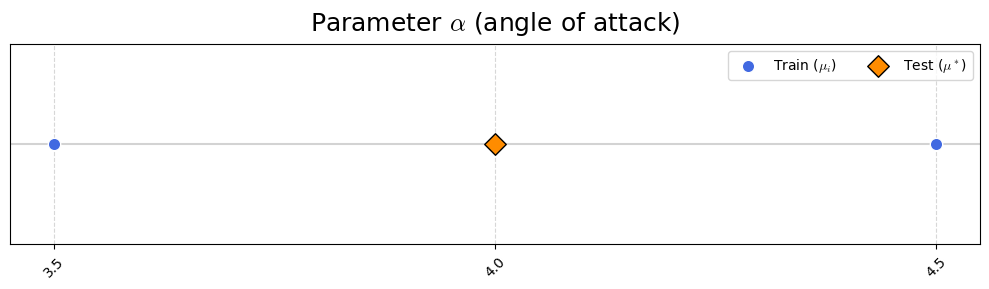

In [2]:

# Parameter set: angles of attack (deg)
alpha_list = np.array([ 3.5, 4.5])   # training
alpha_test = 4.0                                     # test

# Reference data from the OpenFOAM case
U_ref = 242.16629          # m/s
c_ref = 1.0                # m
rho_inf = 0.957837
mu = 7.7319e-5
nu = mu / rho_inf
Re = U_ref * c_ref / nu

U_ref_dict = {alpha: U_ref for alpha in alpha_list}
U_ref_test = U_ref

# Visualization
fig, ax = plt.subplots(figsize=(10, 3))
plt.title('Parameter $\\alpha$ (angle of attack)', fontsize=18, pad=10)

ax.scatter(alpha_list, np.zeros_like(alpha_list),
           marker='o', s=80, color='royalblue', edgecolor='white',
           label='Train ($\mu_i$)', zorder=3)

ax.scatter(alpha_test, 0,
           marker='D', s=120, color='darkorange', edgecolor='black',
           label='Test ($\mu^*$)', zorder=4)

plt.xticks(np.append(alpha_list, alpha_test), rotation=45, fontsize=10)
plt.yticks([])
ax.axhline(0, color='lightgray', linewidth=1.5, zorder=1)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(ncols=2, frameon=True, fontsize=10)
plt.tight_layout()
plt.show()


In [3]:
# Load airfoil geometry

from matplotlib.patches import Polygon
airfoil_path = "/home/haseeb/OpenFOAM/buffet/ONERA-OAT15A-090524/ONERA-OAT15A/ONERA-OAT15A_coordiantes.dat"
airfoil_coords = np.loadtxt(airfoil_path)

x_air = airfoil_coords[:, 0]
y_air = airfoil_coords[:, 1]

def draw_airfoil_patch(ax):
    pts = np.vstack([x_air, y_air]).T
    patch = Polygon(pts, closed=True, facecolor='black', edgecolor='black', zorder=10)
    ax.add_patch(patch)

In [4]:
# Load and prepare data

from Flowtorch_DMD_cylinder_2D_modules.loader_buffet import (
    load_buffet_training_snapshots,
    load_buffet_test_snapshots
)
from Flowtorch_DMD_cylinder_2D_modules.buffet_utils import (
    interpolate_uniform,
    load_force_coeffs
)

# Base folder containing buffet simulations
base_path = os.path.expanduser("~/OpenFOAM/buffet")

# Time window for training
training_window = (0.6, 1.0)

# Sampling step
sampling_step = 1

# Select fields to load
fields = ("Ma", "cl")

# Load training data for all parameters μ ∈ P
train_data, loader0  = load_buffet_training_snapshots(
    param_list=alpha_list,
    base_path=base_path,
    mask_box=mask_box,
    FOAMDataloader=FOAMDataloader,
    training_window=training_window,
    sampling_step=sampling_step,
    fields=fields,
    interpolate_cl=True,
    interpolate_uniform_fn=interpolate_uniform,
    load_force_coeffs_fn=load_force_coeffs
)

# Access training data
X_train_dict   = train_data.snapshots
cl_train_dict  = train_data.cl_train
coords         = train_data.coords
mask_indices   = train_data.mask_indices
num_points     = train_data.num_points
train_times    = train_data.times[alpha_list[0]]
field_info     = train_data.field_info
cell_area      = train_data.cell_area     

# Load test data for unseen parameter μ*
test_data, loader = load_buffet_test_snapshots(
    param=alpha_test,
    base_path=base_path,
    FOAMDataloader=FOAMDataloader,
    train_times=train_times,
    mask_indices=mask_indices,
    coords=coords,
    num_points=num_points,
    fields=fields,
    interpolate_cl=True,
    interpolate_uniform_fn=interpolate_uniform,
    load_force_coeffs_fn=load_force_coeffs
)

# Access test data
X_test          = test_data.snapshots
cl_test         = test_data.cl_test
coords_test     = test_data.coords
num_points_test = test_data.num_points
field_info_test = test_data.field_info
cell_area_test  = test_data.cell_area     


[2026-05-06 22:35:01] INFO     Loading precomputed cell centers and volumes from processor0/constant
[2026-05-06 22:35:01] INFO     Loading precomputed cell centers and volumes from processor1/constant
[2026-05-06 22:35:01] INFO     Loading precomputed cell centers and volumes from processor2/constant
[2026-05-06 22:35:01] INFO     Loading precomputed cell centers and volumes from processor3/constant
[2026-05-06 22:35:01] INFO     Loading precomputed cell centers and volumes from processor4/constant
[2026-05-06 22:35:01] INFO     Loading precomputed cell centers and volumes from processor5/constant
[2026-05-06 22:35:01] INFO     Loading precomputed cell centers and volumes from processor6/constant
[2026-05-06 22:35:01] INFO     Loading precomputed cell centers and volumes from processor7/constant
[2026-05-06 22:35:01] INFO     Loading precomputed cell centers and volumes from processor8/constant
[2026-05-06 22:35:01] INFO     Loading precomputed cell centers and volumes from processor9

Loaded training snapshots for α=3.5° (73803, 201)


[2026-05-06 22:35:11] INFO     Loading precomputed cell centers and volumes from processor0/constant
[2026-05-06 22:35:11] INFO     Loading precomputed cell centers and volumes from processor1/constant
[2026-05-06 22:35:11] INFO     Loading precomputed cell centers and volumes from processor2/constant
[2026-05-06 22:35:11] INFO     Loading precomputed cell centers and volumes from processor3/constant
[2026-05-06 22:35:11] INFO     Loading precomputed cell centers and volumes from processor4/constant
[2026-05-06 22:35:11] INFO     Loading precomputed cell centers and volumes from processor5/constant
[2026-05-06 22:35:11] INFO     Loading precomputed cell centers and volumes from processor6/constant
[2026-05-06 22:35:11] INFO     Loading precomputed cell centers and volumes from processor7/constant
[2026-05-06 22:35:11] INFO     Loading precomputed cell centers and volumes from processor8/constant
[2026-05-06 22:35:11] INFO     Loading precomputed cell centers and volumes from processor9

Loaded training snapshots for α=4.5° (73803, 201)
Loaded test snapshots for α=4.0° (73803, 201)


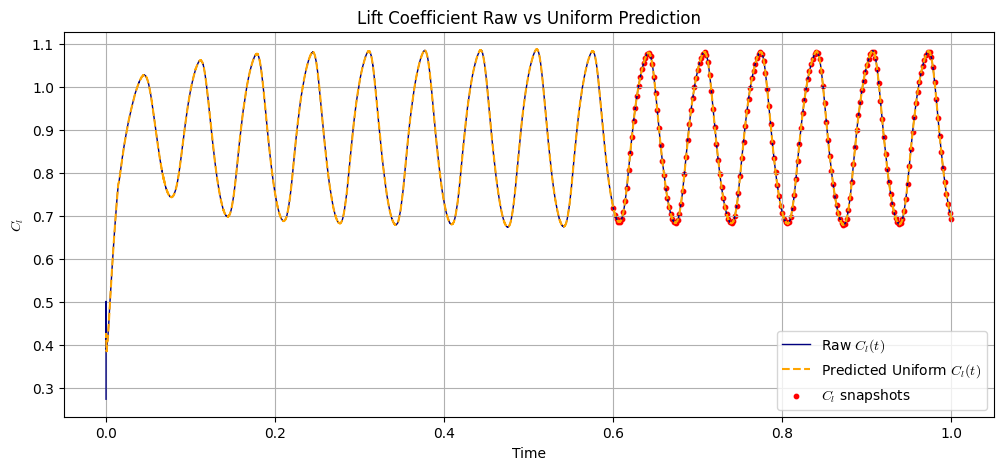

In [5]:
# Plot raw vs uniform Cl for a training parameter

# Extract Cl time histories from loader
t_cl_raw, cl_raw   = train_data.cl_raw
t_cl_uni, cl_uni   = train_data.cl_uniform

# CFD snapshot times for the chosen alpha
train_times = train_data.times[alpha_list[0]]

plt.figure(figsize=(12,5))

# Raw Cl(t) from coefficient.dat
plt.plot(t_cl_raw, cl_raw, lw=1.0, color='navy', label="Raw $C_l(t)$")

# Uniform Cl(t) after interpolation — now dashed
plt.plot(t_cl_uni, cl_uni, lw=1.5, color='orange', linestyle='--',
         label="Predicted Uniform $C_l(t)$")

# Cl(t) sampled at CFD snapshot times (training window)
cl_snap = np.interp(train_times, t_cl_uni, cl_uni)
plt.scatter(train_times, cl_snap, color='red', s=10,
            label="$C_l$ snapshots")

plt.title("Lift Coefficient Raw vs Uniform Prediction")
plt.xlabel("Time")
plt.ylabel("$C_l$")
plt.grid(True)
plt.legend()
plt.show()



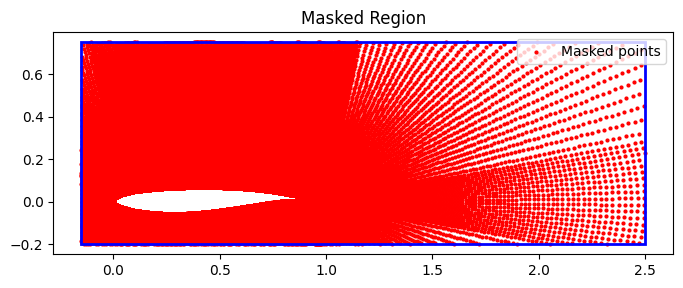

Total masked points: 73803


In [6]:
# Visualize the masked region and the points that are included in the DMD analysis

# Masked points only
masked_pts = train_data.coords

# Bounding box used for masking
xmin, zmin = -0.15, -0.2
xmax, zmax =  2.5,  0.75

plt.figure(figsize=(8,4))

# Plot masked points
plt.scatter(masked_pts[:,0], masked_pts[:,1],
            s=4, c='red', label="Masked points")

# Draw the mask box
rect = patches.Rectangle((xmin, zmin),
                         xmax - xmin,
                         zmax - zmin,
                         linewidth=2, edgecolor='blue',
                         facecolor='none')
plt.gca().add_patch(rect)

plt.title("Masked Region")
plt.legend()
plt.gca().set_aspect('equal')
plt.show()

print("Total masked points:", len(masked_pts))



## Step 2. Train partitioned DMD

For each training parameter $\mu_j \in P = \{\mu_1, \mu_2, \dots, \mu_p\}$ i.e., Reynolds numbers $Re$, the fitted DMD operator is obtained via

$$
A^{(\mu_j)} \;\; \approx \;\; Y^{(\mu_j)} \, \big(X^{(\mu_j)})^{\dagger}
$$


where  
- $\mu_j$ : $j$‑th training parameter in the set $S$  
- $Re$ : Reynolds number corresponding to $\mu_j$  
- $X^{(\mu_j)} \in \mathbb{R}^{n_{\text{space}} \times (n_{\text{time}}-1)}$ : snapshot matrix at times $t_1, \dots, t_{n_{\text{time}}-1}$  
- $Y^{(\mu_j)} \in \mathbb{R}^{n_{\text{space}} \times (n_{\text{time}}-1)}$ : shifted snapshot matrix at times $t_2, \dots, t_{n_{\text{time}}}$  
- $A^{(\mu_j)}$ : DMD regression operator advancing the reduced state forward in time  



In [7]:
dmd_models = {}   # store DMD models per alpha

for alpha in alpha_list:

    # Extract X_train for this alpha
    X_train = X_train_dict[alpha]          # shape (3*num_points, Nt)

    # Extract Cl(t) for this alpha
    cl_train = cl_train_dict[alpha]        # shape (Nt,)
    cl_train_row = cl_train.reshape(1, -1) # shape (1, Nt)

    # Build augmented state
    X_aug = np.vstack([X_train, cl_train_row])

    # Convert to tensor
    X_p = pt.tensor(X_aug, dtype=pt.float64)

    # Time step
    dt = train_data.times[alpha][1] - train_data.times[alpha][0]

    # Fit DMD
    dmd = DMD(X_p, dt=dt, rank=30, tlsq=False, unitary=False, optimal=False, forward_backward=False)

    dmd_models[alpha] = dmd



[2026-05-06 22:35:18] INFO     Computing economy SVD via Gram matrix and eigendecomposition
[2026-05-06 22:35:18] INFO     Truncating SVD at index 30/200
[2026-05-06 22:35:18] INFO     Computing economy SVD via Gram matrix and eigendecomposition
[2026-05-06 22:35:18] INFO     Truncating SVD at index 30/200


In [8]:
# Plot true vs DMD Cl for a training parameter

alpha = alpha_list[0]

# retrieve trained DMD model
dmd = dmd_models[alpha]["dmd"]

# true lift coefficient from CFD
cl_true = cl_train_dict[alpha]

# full DMD reconstruction (augmented state)
X_rec = dmd.reconstruction

# DMD-predicted Cl(t) is the last row; flip to match CFD time direction
cl_pred = X_rec[-1, :].flip(0).cpu().numpy()

# convert time list to numpy array
t = np.array(train_data.times[alpha], dtype=float)

# shift time so that t*=0 at the first sample
t0 = t[0]
t_shifted = t - t0

# non-dimensional time: t* = (t - t0) U_inf / c
t_star = t_shifted * U_ref / c_ref

# create figure and axis
fig, ax = plt.subplots(figsize=(10, 4))

# true Cl(t*) in black
ax.plot(t_star, cl_true,
        color='black', linewidth=2,
        label=r"True")

# DMD Cl(t*) in red dashed
ax.plot(t_star, cl_pred,
        color='red', linestyle='--', linewidth=2,
        label=r"DMD")

# axis labels
ax.set_xlabel(r"$t^{*} = t U_{\infty}/c$", fontsize=13)
ax.set_ylabel(r"$C_L$", fontsize=13)

# title with angle of attack
ax.set_title(f"Lift Coefficient Comparison \n $training$ Parameter ($\\alpha = {alpha}^\\circ$)", fontsize=15)

# grid and legend
ax.grid(True, alpha=0.6)
ax.legend(loc="upper right", fontsize=11)


# clean x-limits and ticks
ax.set_xlim(t_star[0], t_star[-1])
ax.set_xticks(np.linspace(t_star[0], t_star[-1], 6))

plt.tight_layout()
plt.show()


TypeError: 'DMD' object is not subscriptable

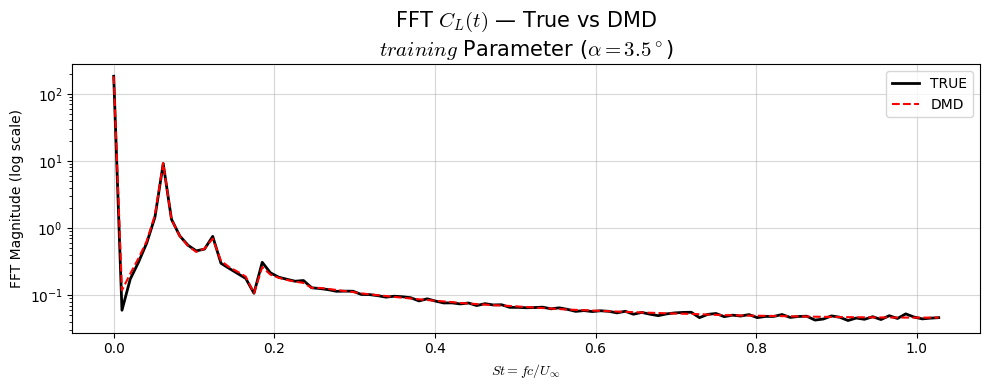

In [ ]:
# Plot FFT of true vs DMD Cl for a training parameter

alpha_ref = 3.5 

# TRUE Cl(t)
Cl_true = cl_train_dict[alpha_ref]
time_vec = np.array(train_data.times[alpha_ref], dtype=float)
dt = time_vec[1] - time_vec[0]

# DMD model
dmd = dmd_models[alpha_ref]["dmd"]

# DMD reconstruction 
modes = dmd.modes.detach().cpu().numpy()
dynamics = dmd.dynamics.detach().cpu().numpy()

# FlowTorch dynamics are reversed
dynamics_flipped = np.flip(dynamics, axis=1)

# Correct forward-time reconstruction
X_dmd = np.real(modes @ dynamics_flipped)

# Cl is the LAST row
Cl_dmd = X_dmd[-1, :]

# FFT (dimensional)
freqs = np.fft.rfftfreq(len(Cl_true), d=dt)
fft_true = np.abs(np.fft.rfft(Cl_true))
fft_dmd  = np.abs(np.fft.rfft(Cl_dmd))

# Non-dimensional frequency (Strouhal)
St = freqs * c_ref / U_ref

# Plot
plt.figure(figsize=(10,4))
plt.semilogy(St, fft_true, label="TRUE", color="black", linewidth=2)
plt.semilogy(St, fft_dmd,  label="DMD",  color="red", linestyle="--")

plt.xlabel(r"$St = f c / U_{\infty}$")
plt.ylabel("FFT Magnitude (log scale)")
plt.title(
    f"FFT $C_L(t)$ — True vs DMD\n"
    f"$training$ Parameter ($\\alpha = {alpha_ref}^\\circ$)",
    fontsize=15
)

plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


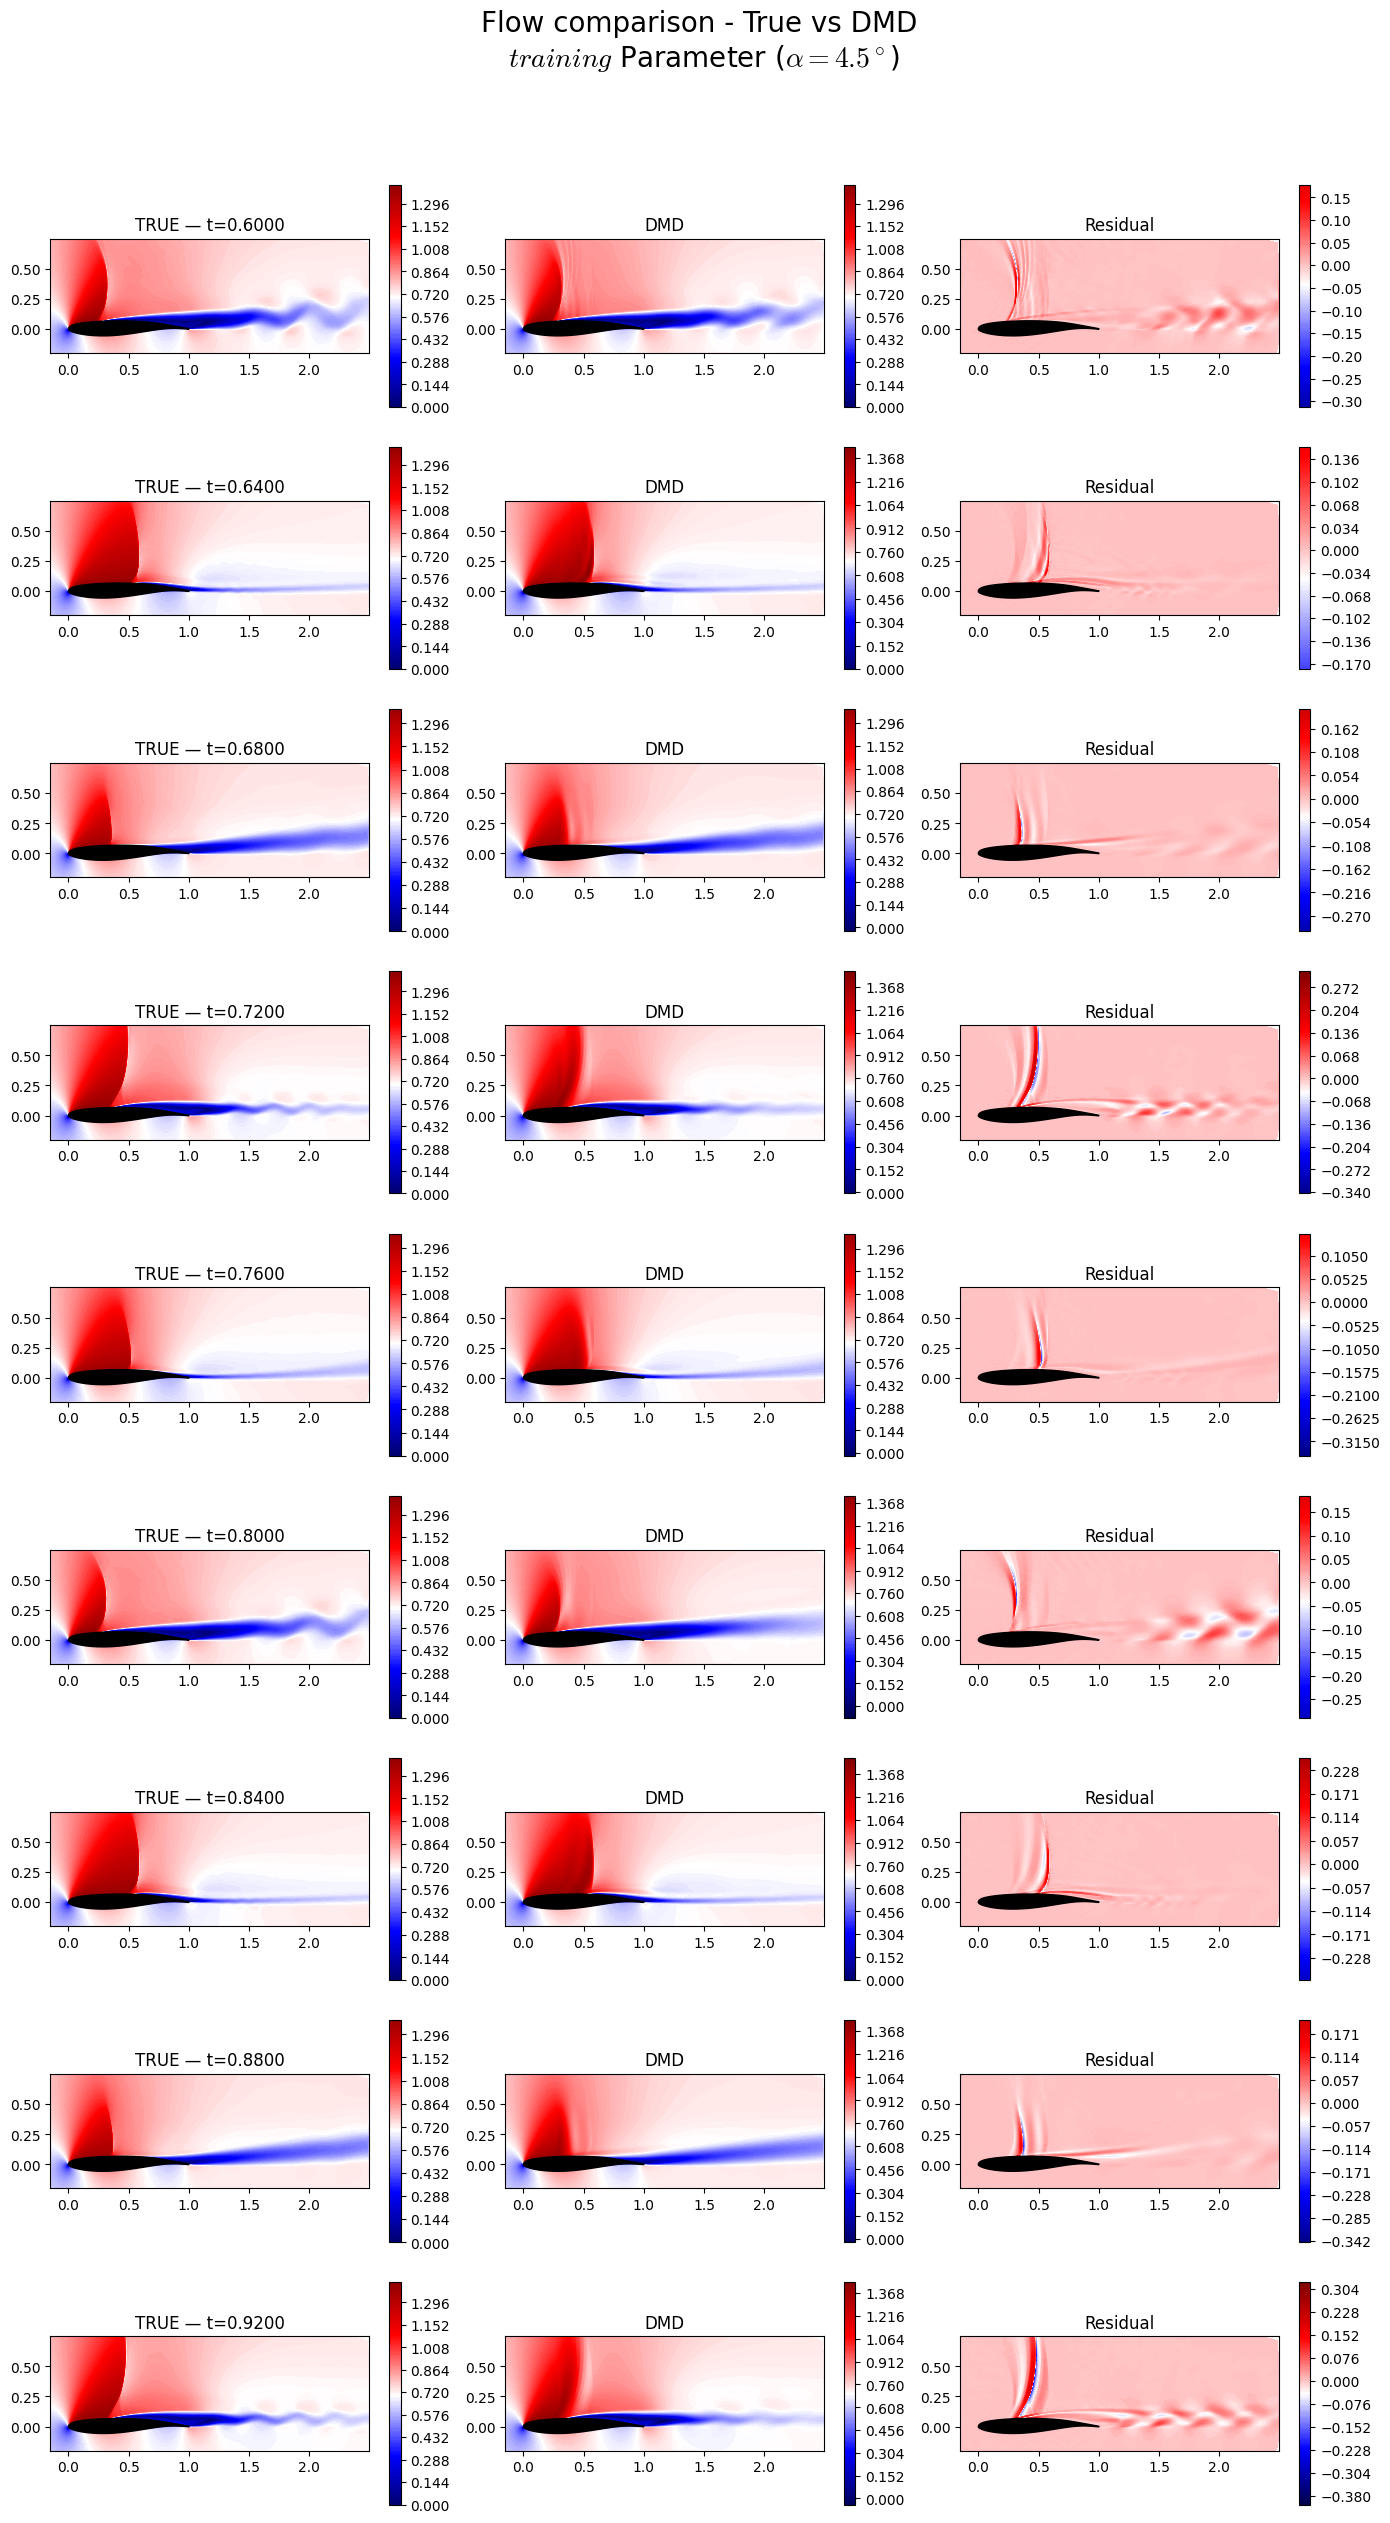

In [ ]:
# USER INPUT
alpha_ref = alpha_list[1]
field = "Ma"
indices = [0, 20, 40, 60]

# Extract data
X_true = train_data.snapshots[alpha_ref]
Cl_true = train_data.cl_train[alpha_ref]
coords = train_data.coords
times = np.array(train_data.times[alpha_ref], dtype=float)
num_points = train_data.num_points

# Augmented TRUE state
X_true_aug = np.vstack([X_true, Cl_true.reshape(1, -1)])

# DMD reconstruction (flipped)
dmd = dmd_models[alpha_ref]
modes = dmd.modes.detach().cpu().numpy()
dynamics = dmd.dynamics.detach().cpu().numpy()
dynamics = np.flip(dynamics, axis=1)
X_dmd = np.real(modes @ dynamics)

# Field lookup
field_names = [f[0] for f in field_info]
idx = field_names.index(field)
_, ftype, dim = field_info[idx]

# Field extractor
def extract_field(X, snap):
    start = sum(d * num_points for _,_,d in field_info[:idx])
    block = X[start:start + dim*num_points, snap]
    if ftype == "scalar":
        return block
    else:
        comps = [block[i*num_points:(i+1)*num_points] for i in range(dim)]
        return np.sqrt(sum(c**2 for c in comps))

# Interpolation grid
x = coords[:,0]
z = coords[:,1]
nx, nz = 300, 300
xi = np.linspace(x.min(), x.max(), nx)
zi = np.linspace(z.min(), z.max(), nz)
XI, ZI = np.meshgrid(xi, zi)

# Precompute magnitudes
true_mags, dmd_mags, resid_mags = [], [], []
for snap in indices:
    t_field = extract_field(X_true_aug, snap)
    d_field = extract_field(X_dmd, snap)
    true_mags.append(t_field)
    dmd_mags.append(d_field)
    resid_mags.append(t_field - d_field)

# Global color limits
vmin = min(m.min() for m in true_mags + dmd_mags)
vmax = max(m.max() for m in true_mags + dmd_mags)
resid_min = min(m.min() for m in resid_mags)
resid_max = max(m.max() for m in resid_mags)

# Plot
n = len(indices)
fig, axes = plt.subplots(n, 3, figsize=(14, 3*n))
fig.suptitle(f"Flow comparison - True vs DMD \n$training$ Parameter ($\\alpha = {alpha_ref}^\\circ$)", fontsize=20, y=0.97)

for row, snap in enumerate(indices):

    # TRUE
    ax = axes[row, 0]
    c = ax.tricontourf(coords[:,0], coords[:,1], true_mags[row],
                    levels=300, cmap="seismic",
                    vmin=vmin, vmax=vmax)
    draw_airfoil_patch(ax)
    ax.set_aspect("equal")
    ax.set_title(f"TRUE — t={times[snap]:.4f}")
    fig.colorbar(c, ax=ax, shrink=0.8)

    # DMD
    ax = axes[row, 1]
    c = ax.tricontourf(coords[:,0], coords[:,1], dmd_mags[row],
                    levels=300, cmap="seismic",
                    vmin=vmin, vmax=vmax)
    draw_airfoil_patch(ax)
    ax.set_aspect("equal")
    ax.set_title("DMD (flipped)")
    fig.colorbar(c, ax=ax, shrink=0.8)

    # RESIDUAL
    ax = axes[row, 2]
    c = ax.tricontourf(coords[:,0], coords[:,1], resid_mags[row],
                    levels=300, cmap="seismic",
                    vmin=resid_min, vmax=resid_max)
    draw_airfoil_patch(ax)
    ax.set_aspect("equal")
    ax.set_title("Residual (TRUE − DMD)")
    fig.colorbar(c, ax=ax, shrink=0.8)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



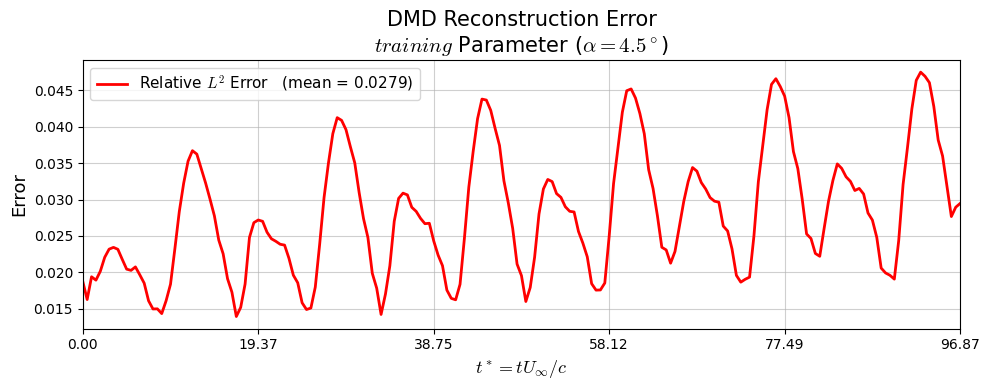

In [ ]:
# Plot DMD reconstruction error for a training parameter



# USER SELECTED α
alpha_ref = alpha_list[1]

# TRUE snapshot matrix (augmented)
X_true = np.vstack([
    X_train_dict[alpha_ref],                 # flow field
    cl_train_dict[alpha_ref].reshape(1, -1)  # Cl(t)
])

# DMD reconstruction FlowTorch reversed Vandermonde 
X_dmd_full = dmd_models[alpha_ref].reconstruction.detach().cpu().numpy()
X_dmd = np.flip(X_dmd_full, axis=1)   #

# Time vector
t = np.array(train_data.times[alpha_ref], float)
t = t - t[0]   # shift to start at 0

# Non-dimensional time t* = t U_inf / c
U_inf = U_ref      
L_ref = c_ref      
t_star = t * U_inf / L_ref

# Reconstruction error
abs_error = np.linalg.norm(X_true - X_dmd, axis=0)
rel_error = abs_error / np.linalg.norm(X_true, axis=0)

# Mean relative error
mean_rel = np.mean(rel_error)

# PLOT
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(t_star, rel_error,
        color='red', linewidth=2,
        label=f'Relative $L^2$ Error (mean = {mean_rel:.4f})')

ax.set_xlabel(r"$t^* = t U_{\infty}/c$", fontsize=13)
ax.set_ylabel("Error", fontsize=13)
ax.set_title(f"Reconstruction Error - True vs DMD\n$training$ Parameter ($\\alpha = {alpha_ref}^\\circ$)", fontsize=15)

ax.grid(True, alpha=0.6)
ax.legend(fontsize=11)

ax.set_xlim(t_star[0], t_star[-1])
ax.set_xticks(np.linspace(t_star[0], t_star[-1], 6))

plt.tight_layout()
plt.show()


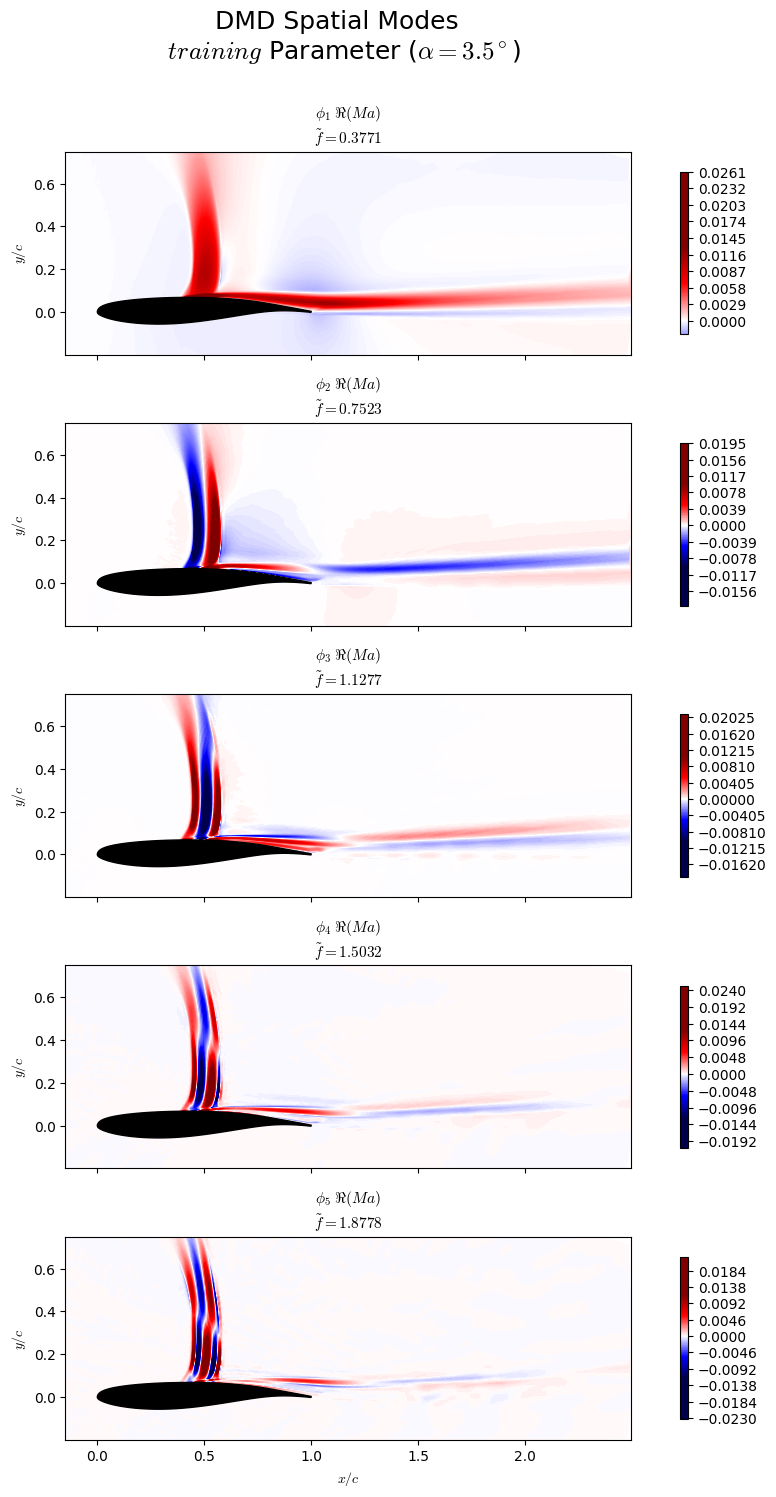

In [10]:

# USER INPUT
alpha_target = 3.5
field = "Ma"
num_to_plot = 5

# load the DMD model and geometry
dmd = dmd_models[alpha_target]
coords_fluid = coords
num_fluid = num_points

# extract DMD data
modes = dmd.modes.detach().cpu().numpy()
freqs = dmd.frequency.detach().cpu().numpy()

# rank all modes using FlowTorch's top_modes logic
num_modes = modes.shape[1]
sorted_modes = dmd.top_modes(n=num_modes, integral=True).cpu().numpy()

# keep only positive-frequency modes
positive_modes = [m for m in sorted_modes if freqs[m] > 0]
positive_modes = positive_modes[:num_to_plot]

# determine field block location
field_names = [f[0] for f in field_info]
idx = field_names.index(field)
_, ftype, dim = field_info[idx]

offset = sum(d * num_fluid for _, _, d in field_info[:idx])
field_size = dim * num_fluid

# plotting layout
ncols = 2 if field == "U" else 1
nrows = len(positive_modes)

fig, axarr = plt.subplots(nrows, ncols, figsize=(10, 3*nrows),
                          sharex=True, sharey=True)

if nrows == 1:
    axarr = np.array([axarr])
if ncols == 1:
    axarr = axarr.reshape(nrows, 1)

# loop over ranked positive-frequency modes
for row, m in enumerate(positive_modes):

    # extract mode and remove Cl row
    mode_k = modes[:, m]
    mode_flow = mode_k[:-1]

    # extract selected field block (no weighting)
    block = mode_flow[offset : offset + field_size]

    # compute normalized frequency
    f_tilde = 2 * np.pi * freqs[m] * c_ref / U_ref

    # handle scalar or vector fields
    if field == "U":
        Ux = np.real(block[0*num_fluid : 1*num_fluid])
        Uz = np.real(block[2*num_fluid : 3*num_fluid])
        fields_to_plot = [("Ux", Ux), ("Uz", Uz)]
    else:
        scalar_field = np.real(block)
        fields_to_plot = [(field, scalar_field)]

    # plot each component
    for col, (label, data) in enumerate(fields_to_plot):

        data = np.asarray(data)
        lim = np.max(np.abs(data))*0.5

        ax = axarr[row, col]

        c = ax.tricontourf(coords_fluid[:, 0], coords_fluid[:, 1], data,
                           levels=300, cmap="seismic",
                           vmin=-lim, vmax=lim)

        draw_airfoil_patch(ax)
        ax.set_aspect("equal")

        ax.set_title(
            rf"$\phi_{row+1}\ \Re({label})$" "\n"
            rf"$\tilde f = {f_tilde:.4f}$",
            fontsize=11
        )

        fig.colorbar(c, ax=ax, shrink=0.8)

# axis labels
for ax in axarr[:, 0]:
    ax.set_ylabel("$y/c$")
for ax in axarr[-1, :]:
    ax.set_xlabel("$x/c$")

plt.suptitle(
    f"DMD Spatial Modes \n $training$ Parameter ($\\alpha = {alpha_target}^\\circ$)",
    fontsize=18, y=0.995
)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()


In [11]:
# Step 3 — Prepare modes/eigs for alignment (sorting + pairing + alignment) 

from Flowtorch_DMD_cylinder_2D_modules.mode_eigs_prep import mode_eigs_prep

modes_dict = {
    alpha: dmd_models[alpha].modes.detach().cpu().numpy()
    for alpha in alpha_list
}

eigs_dict = {
    alpha: dmd_models[alpha].eigvals_cont.detach().cpu().numpy()
    for alpha in alpha_list
}

dmd_dict = {alpha: dmd_models[alpha] for alpha in alpha_list}

rank = dmd_models[alpha_list[0]].svd.rank

prep = mode_eigs_prep(
    parameter_list = alpha_list,
    parameter_test = alpha_test,
    modes_dict     = modes_dict,
    eigs_dict      = eigs_dict,
    rank           = rank
).fit(dmd_dict)

aligned_modes_dict, aligned_eigs_dict = prep.aligned


In [12]:

# Step 4.1 — Interpolate modes/eigs for unseen parameter using Lagrange polynomial interpolation
from Flowtorch_DMD_cylinder_2D_modules.lagrange_interp import lagrange_interp


# Dummy x0 (never used, but required by the class)
x0_dummy = {alpha: np.zeros(aligned_modes_dict[alpha].shape[0]) for alpha in alpha_list}

interp = lagrange_interp(
    parameter_list = alpha_list,
    parameter_test = alpha_test,
    aligned_modes  = aligned_modes_dict,
    aligned_eigs   = aligned_eigs_dict,
    x_0            = x0_dummy,      # dummy, ignored
    stencil_sizes  = [2]
).fit()

interp_modes = interp.modes
interp_eigs  = interp.eigs


In [14]:
# Step 4.2 — Initial condition x_0 for unseen parameter α*

x0_true_dict = {}
for alpha in alpha_list:
    x_flow = X_train_dict[alpha][:, 0]      
    x_cl   = cl_train_dict[alpha][0]        
    x0_true_dict[alpha] = np.hstack([x_flow, x_cl])  

# Identify the closest neighbor α_j closest to α*.
closest_alpha = min(alpha_list, key=lambda a: abs(a - alpha_test))

# Extract the augmented initial condition x_0 from that closest neighbor used for reconstruction at α*.
neighbor_x0 = x0_true_dict[closest_alpha]



In [15]:
# Reconstruction for the unseen parameter 

# Choose reconstruction rank
r_recon = 30      

recon_results_aligned   = {}
recon_results_unaligned = {}

# Spatial dimension of the augmented state (Ux, Uz, Cl)
n_space = neighbor_x0.shape[0]

# Flow dimension exclude Cl
n_flow = n_space - 1
half   = n_flow // 2     # number of Ux-points = number of Uz-points

# Time vector for reconstruction (use training window times)
t_vec = np.array(train_times, dtype=float)

# Initial time
t0 = t_vec[0]


# Loop over stencil sizes
for Np in interp_modes.keys():     # <-- FIXED

    # Φ^(α*): interpolated modes at target α
    Phi_aligned_full = interp_modes[Np]

    # Truncate to selected rank
    Phi_aligned = Phi_aligned_full[:, :r_recon]

    # s^(α*): interpolated continuous-time eigenvalues
    s_aligned_full = interp_eigs[Np]

    # Truncate eigenvalues
    s_aligned = s_aligned_full[:r_recon]

    # x0^(α*): initial condition at target α* (taken from closest neighbor)
    x_0 = neighbor_x0

    # Φ†: pseudoinverse of interpolated modes
    Phi_aligned_pinv = np.linalg.pinv(Phi_aligned)

    # Allocate reconstruction arrays
    X_recon_aligned = np.zeros((n_space, len(t_vec)), dtype=complex)

    # Reconstruction formula:
    #   x(t_k) = Φ^(α*) diag(exp(s^(α*) (t_k - t_0))) Φ^(α*)† x_0^(α*)

    for k, t in enumerate(t_vec):

        # exp(s (t - t0)) 
        expS_aligned = np.exp(s_aligned * (t - t0))

        # x(t_k) = Φ (exp(s (t_k - t0)) ⊙ (Φ† x0))
        X_recon_aligned[:, k] = Phi_aligned @ (expS_aligned * (Phi_aligned_pinv @ x_0))

    # Store reconstructions
    recon_results_aligned[Np] = X_recon_aligned


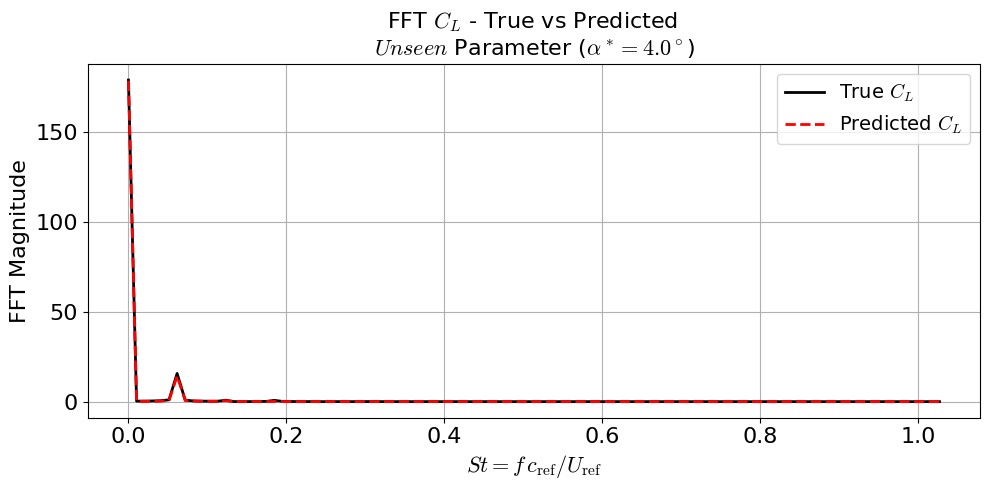

In [16]:
# FFT comparison: True Cl (test case) vs Predicted Cl (DMD)

Np_choice = 2

# True Cl(t)
Cl_true  = np.real(cl_test)
t_true   = np.array(train_times, float)

# Predicted Cl(t)
X_recon_aug = recon_results_aligned[Np_choice]
Cl_recon = np.real(X_recon_aug[-1, :])

# FFT parameters
dt = t_true[1] - t_true[0]
freqs = np.fft.rfftfreq(len(Cl_true), d=dt)      # dimensional frequency [Hz]

# Convert to Strouhal number
St = freqs * c_ref / U_ref

# FFT magnitudes
fft_true  = np.abs(np.fft.rfft(Cl_true))
fft_recon = np.abs(np.fft.rfft(Cl_recon))

# Plot FFT comparison (MATCHING YOUR FIRST BLOCK EXACTLY)
plt.figure(figsize=(10,5))

plt.plot(St, fft_true,
         label="True $C_L$",
         linewidth=2,
         color="black")

plt.plot(St, fft_recon,
         label="Predicted $C_L$",
         linestyle='--',
         linewidth=2,
         color="red")

# Tick font sizes
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tick_params(axis='both', which='minor', labelsize=16)

plt.xlabel(r"$St = f\,c_{\mathrm{ref}} / U_{\mathrm{ref}}$", fontsize=16)
plt.ylabel(r"FFT Magnitude", fontsize=16)

plt.title(
    f"FFT $C_L$ - True vs Predicted \n$Unseen$ Parameter ($\\alpha^* = {alpha_test}^\\circ$)",
    fontsize=16
)

plt.legend(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


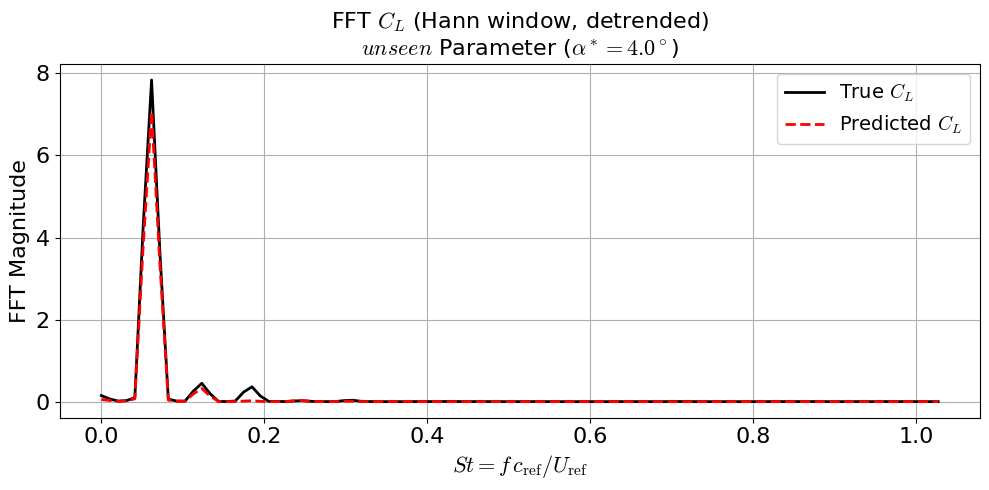

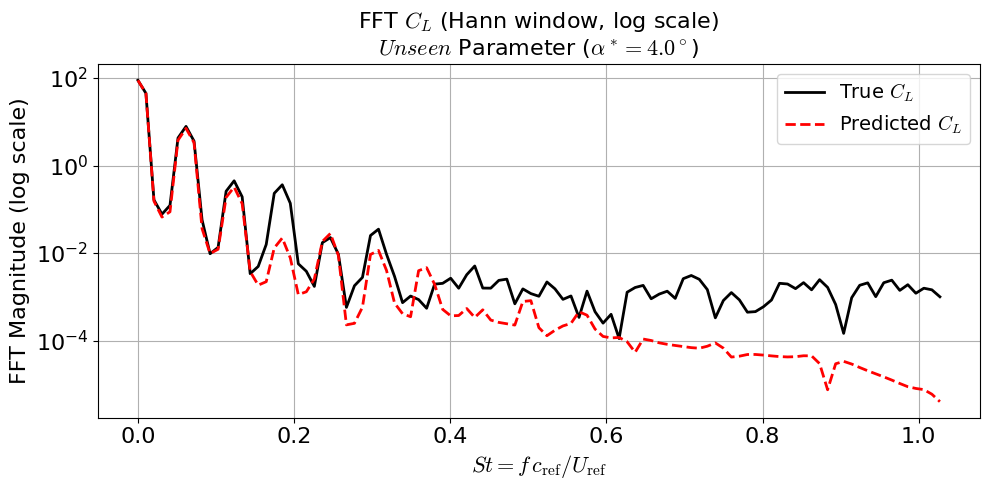

In [17]:
# FFT comparison of Cl for True vs MRPWI reconstruction of unseen parameter


Np_choice = 2

# True Cl(t)
Cl_true  = np.real(cl_test)
t_true   = np.array(train_times, float)

# Reconstructed Cl(t)
Cl_recon = np.real(recon_results_aligned[Np_choice][-1, :])

# Ensure matching time vectors
if len(Cl_true) != len(Cl_recon):
    Cl_true = np.interp(t_true, t_true, Cl_true)

dt = t_true[1] - t_true[0]
freqs = np.fft.rfftfreq(len(Cl_true), d=dt)

# Convert to Strouhal number
St = freqs * c_ref / U_ref

# Detrend + Hann window
Cl_true_d  = Cl_true  - Cl_true.mean()
Cl_recon_d = Cl_recon - Cl_recon.mean()

window = np.hanning(len(Cl_true))
Cl_true_w  = Cl_true_d  * window
Cl_recon_w = Cl_recon_d * window

fft_true  = np.abs(np.fft.rfft(Cl_true_w))
fft_recon = np.abs(np.fft.rfft(Cl_recon_w))

plt.figure(figsize=(10,5))

plt.plot(St, fft_true,
         label="True $C_L$",
         linewidth=2,
         color="black")

plt.plot(St, fft_recon,
         label="Predicted $C_L$",
         linestyle='--',
         linewidth=2,
         color="red")

# Tick font sizes
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tick_params(axis='both', which='minor', labelsize=16)

plt.xlabel(r"$St = f\,c_{\mathrm{ref}} / U_{\mathrm{ref}}$", fontsize=16)
plt.ylabel(r"FFT Magnitude", fontsize=16)

plt.title(
    f"FFT $C_L$ (Hann window, detrended)\n$unseen$ Parameter ($\\alpha^* = {alpha_test}^\\circ$)",
    fontsize=16
)

plt.legend(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

# Hann window only (log scale)

Cl_true_w2  = Cl_true  * window
Cl_recon_w2 = Cl_recon * window

fft_true2  = np.abs(np.fft.rfft(Cl_true_w2))
fft_recon2 = np.abs(np.fft.rfft(Cl_recon_w2))

plt.figure(figsize=(10,5))

plt.plot(St, fft_true2,
         label="True $C_L$",
         linewidth=2,
         color="black")

plt.plot(St, fft_recon2,
         label="Predicted $C_L$",
         linestyle='--',
         linewidth=2,
         color="red")

plt.yscale("log")

# Tick font sizes
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tick_params(axis='both', which='minor', labelsize=16)

plt.xlabel(r"$St = f\,c_{\mathrm{ref}} / U_{\mathrm{ref}}$", fontsize=16)
plt.ylabel(r"FFT Magnitude (log scale)", fontsize=16)

plt.title(
    f"FFT $C_L$ (Hann window, log scale)\n$Unseen$ Parameter ($\\alpha^* = {alpha_test}^\\circ$)",
    fontsize=16
)

plt.legend(fontsize=14)
plt.grid(True, which='both')
plt.tight_layout()
plt.show()


Best lag (samples): 9
Best lag (seconds): 0.018000


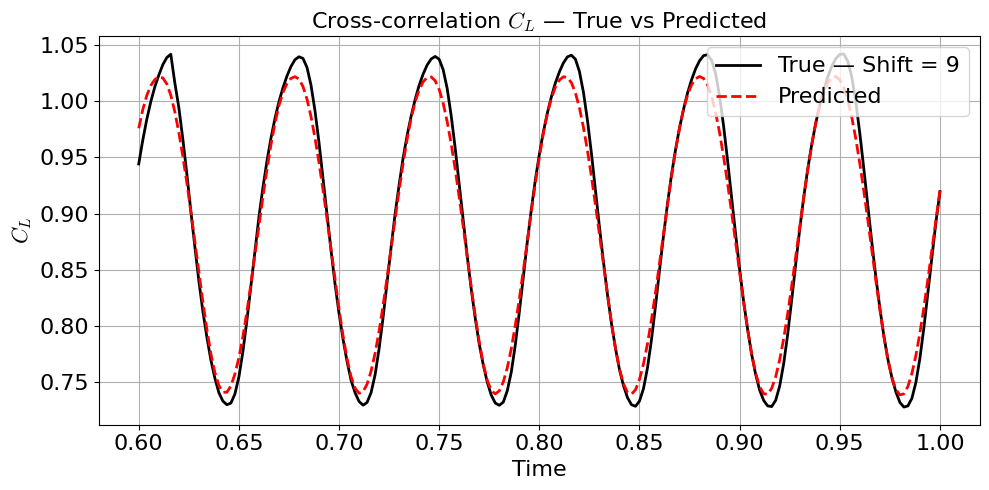

In [18]:
# Cross-correlation and time alignment of Cl signals for True vs MRPWI reconstruction of unseen parameter

# True and reconstructed signals
Cl_true  = np.real(cl_test)
t_true   = np.array(train_times, float)   # ensure correct time vector

Cl_recon = np.real(X_recon_aligned[-1, :])
t_recon  = t_vec.copy()

# Align time vectors 
if len(Cl_true) != len(Cl_recon):
    Cl_true = np.interp(t_recon, t_true, Cl_true)
    t_true  = t_recon.copy()

dt = t_true[1] - t_true[0]

# Detrend (remove mean)
Cl_true_d  = Cl_true  - np.mean(Cl_true)
Cl_recon_d = Cl_recon - np.mean(Cl_recon)

# CROSS-CORRELATION
corr = np.correlate(Cl_recon_d, Cl_true_d, mode='full')
lags = np.arange(-len(Cl_true_d) + 1, len(Cl_recon_d))

best_idx = np.argmax(corr)
best_lag = lags[best_idx]   # >0 means recon is delayed vs true

# Shift the TRUE signal to best match the reconstructed one
Cl_true_shifted = np.roll(Cl_true, best_lag)

print(f"Best lag (samples): {best_lag}")
print(f"Best lag (seconds): {best_lag * dt:.6f}")

# ZOOMED PLOT FOR VISUAL CHECK
zoom_start = t_true[0]
zoom_end   = t_true[0] + 0.5   # adjust as needed

mask = (t_true >= zoom_start) & (t_true <= zoom_end)

plt.figure(figsize=(10,5))

plt.plot(t_true[mask], Cl_true_shifted[mask],
         label=f"True — Shift = {best_lag}",
         linewidth=2,
         color="black")

plt.plot(t_recon[mask], Cl_recon[mask],
         '--',
         label="Predicted",
         linewidth=2,
         color="red")

plt.xlabel("Time", fontsize=16)
plt.ylabel("$C_L$", fontsize=16)
plt.title("Cross-correlation $C_L$ — True vs Predicted", fontsize=16)

plt.legend(loc="upper right", fontsize=16)
plt.grid(True)

# Tick font sizes
plt.tick_params(axis='both', which='major', labelsize=16)
plt.tick_params(axis='both', which='minor', labelsize=16)

plt.tight_layout()
plt.show()


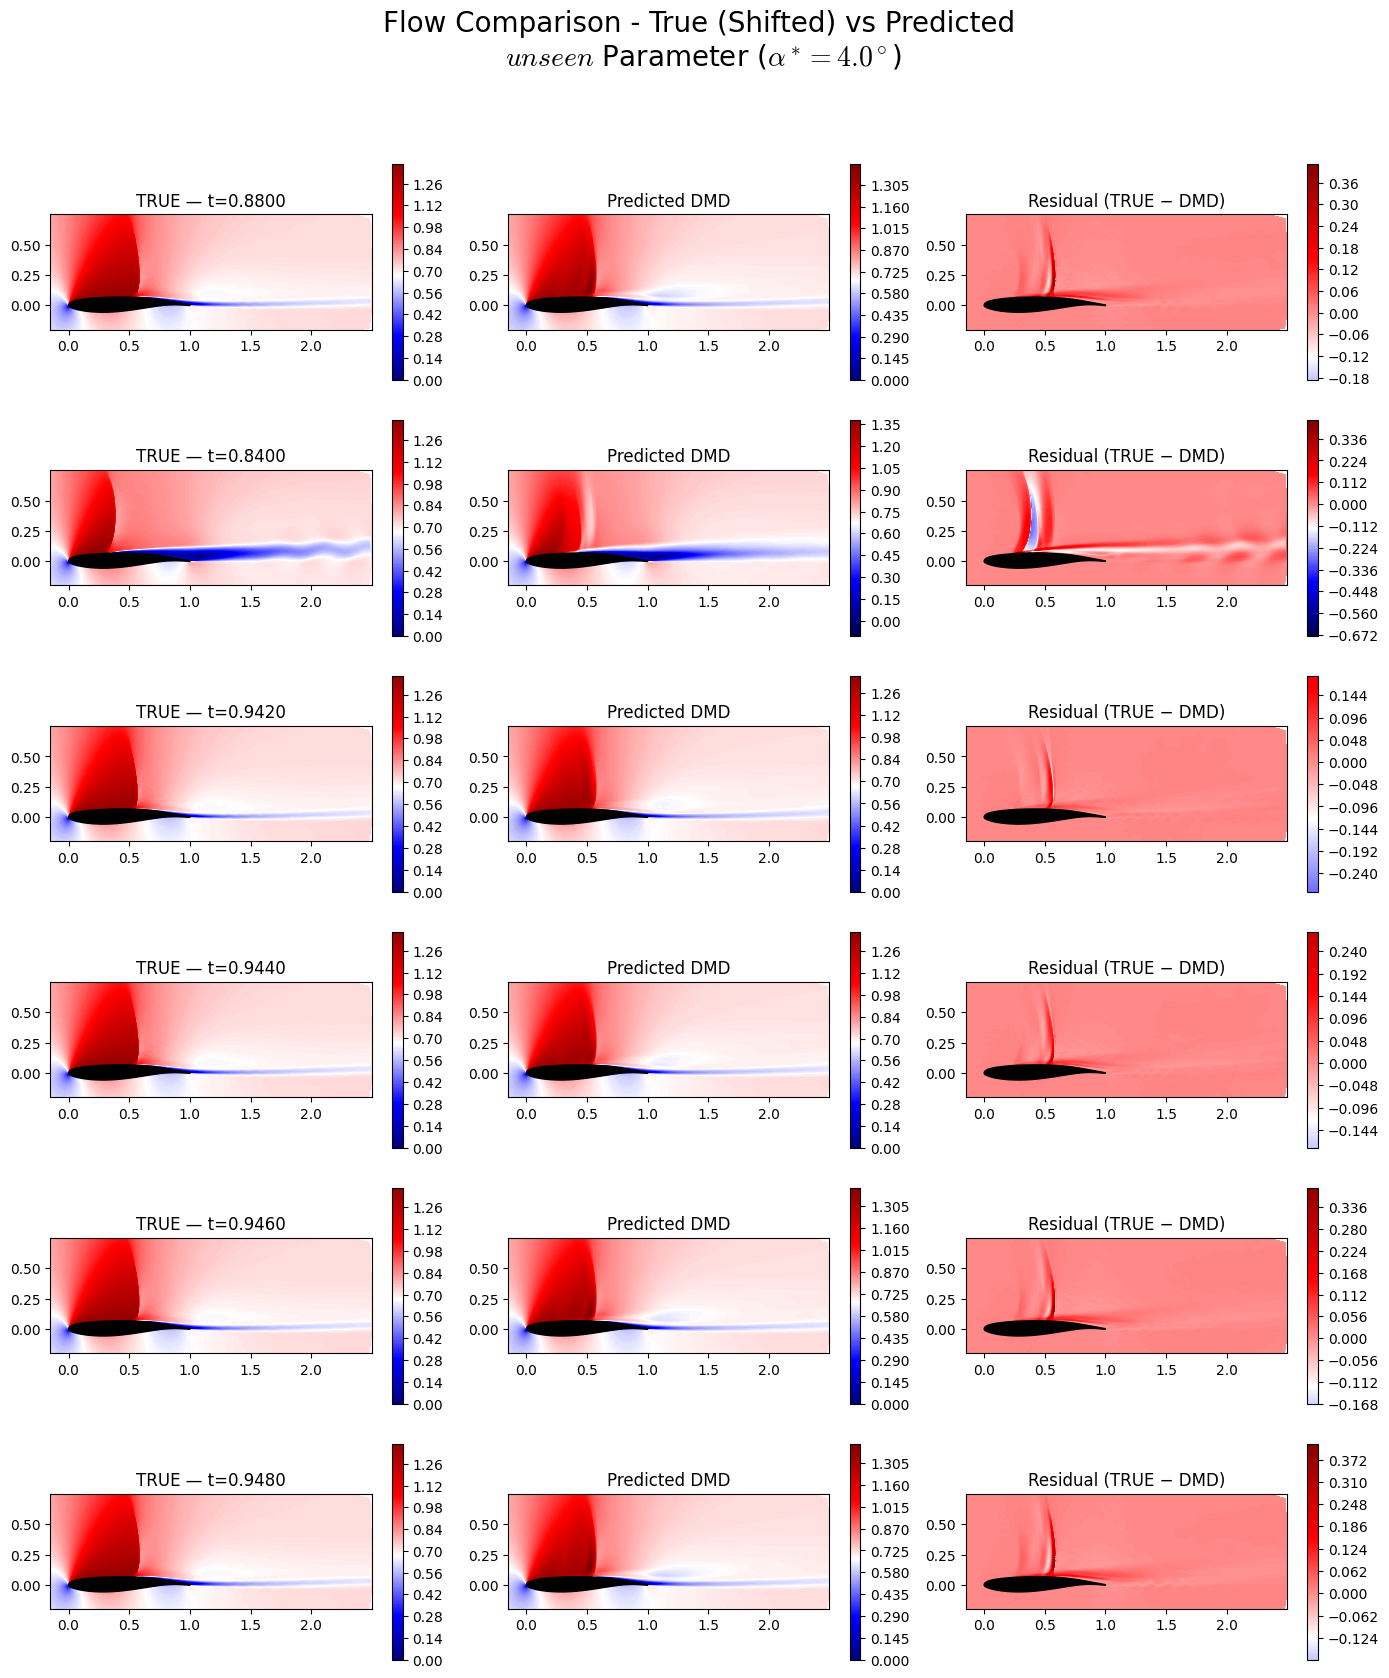

In [19]:
# Plot flow comparison of True vs MRPWI for the unseen parameter, using the time-aligned TRUE snapshots 

# USER INPUT
Np_choice = 2
field     = "Ma"
indices   = [140, 120, 171, 172, 173, 174]

# Precomputed shift
# best_lag must already be computed from cross‑correlation
X_true_shifted = np.roll(X_test, best_lag, axis=1)   

# TRUE Cl(t) also available if needed
Cl_true = cl_test
coords = coords_test
times  = np.array(train_times, dtype=float)
num_points = num_points_test

# DMD reconstruction (flow only, already aligned)
X_dmd = np.real(recon_results_aligned[Np_choice])[:-1, :]

# Field lookup
field_names = [f[0] for f in field_info]
idx = field_names.index(field)
_, ftype, dim = field_info[idx]

# Field extractor
def extract_field(X, snap):
    start = sum(d * num_points for _,_,d in field_info[:idx])
    block = X[start:start + dim*num_points, snap]
    if ftype == "scalar":
        return block
    else:
        comps = [block[i*num_points:(i+1)*num_points] for i in range(dim)]
        return np.sqrt(sum(c**2 for c in comps))

# Precompute magnitudes
true_mags, dmd_mags, resid_mags = [], [], []
for snap in indices:
    t_field = extract_field(X_true_shifted, snap)  
    d_field = extract_field(X_dmd, snap)
    true_mags.append(t_field)
    dmd_mags.append(d_field)
    resid_mags.append(t_field - d_field)

# Global color limits
vmin = min(m.min() for m in true_mags + dmd_mags)
vmax = max(m.max() for m in true_mags + dmd_mags)
resid_min = min(m.min() for m in resid_mags)
resid_max = max(m.max() for m in resid_mags)

# Plot
n = len(indices)
fig, axes = plt.subplots(n, 3, figsize=(14, 3*n))
fig.suptitle(
    f"Flow Comparison - True (Shifted) vs Predicted \n$unseen$ Parameter ($\\alpha^* = {alpha_test}^\\circ$)",
    fontsize=20, y=0.97
)

for row, snap in enumerate(indices):

    # TRUE
    ax = axes[row, 0]
    c = ax.tricontourf(coords[:,0], coords[:,1], true_mags[row],
                       levels=300, cmap="seismic",
                       vmin=vmin, vmax=vmax)
    draw_airfoil_patch(ax)
    ax.set_aspect("equal")
    ax.set_title(f"TRUE — t={times[snap]:.4f}")
    fig.colorbar(c, ax=ax, shrink=0.8)

    # DMD
    ax = axes[row, 1]
    c = ax.tricontourf(coords[:,0], coords[:,1], dmd_mags[row],
                       levels=300, cmap="seismic",
                       vmin=vmin, vmax=vmax)
    draw_airfoil_patch(ax)
    ax.set_aspect("equal")
    ax.set_title("Predicted DMD")
    fig.colorbar(c, ax=ax, shrink=0.8)

    # RESIDUAL
    ax = axes[row, 2]
    c = ax.tricontourf(coords[:,0], coords[:,1], resid_mags[row],
                       levels=300, cmap="seismic",
                       vmin=resid_min, vmax=resid_max)
    draw_airfoil_patch(ax)
    ax.set_aspect("equal")
    ax.set_title("Residual (TRUE − DMD)")
    fig.colorbar(c, ax=ax, shrink=0.8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


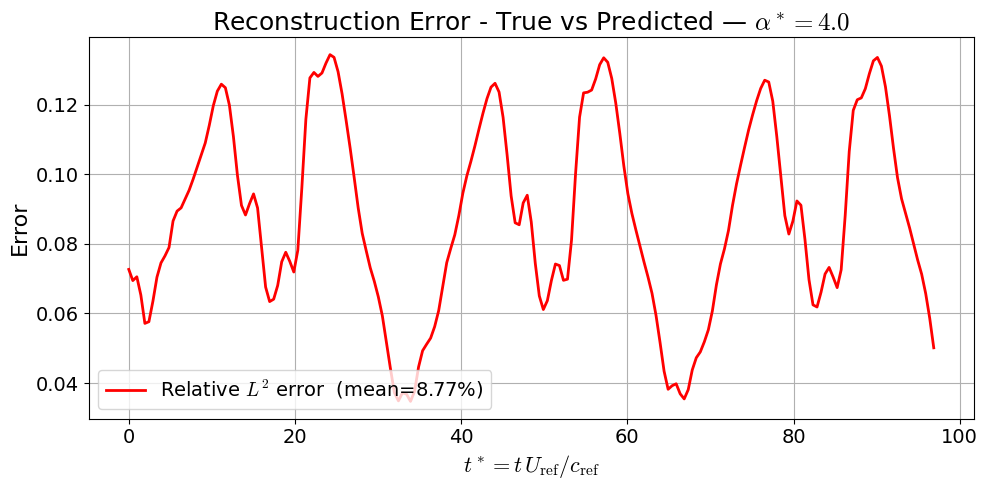

In [ ]:
# Plot reconstruction error for unseen parameter

time_errors = {}
mean_errors = {}

# Non-dimensional time: t* = t U_ref / c_ref
t_nd = t_true * U_ref / c_ref

for Np in interp_modes.keys():

    # True aligned flow (Ux, Uz)
    X_true = X_true_shifted                     # shape (n_space-1, n_time)

    # Predicted aligned flow (remove Cl row)
    X_pred = recon_results_aligned[Np][:-1, :]  # same shape

    # Time‑resolved relative error: ||pred - true|| / ||true||
    err_t = np.linalg.norm(X_pred - X_true, axis=0) / np.linalg.norm(X_true, axis=0)

    time_errors[Np] = err_t
    mean_errors[Np] = np.mean(err_t) * 100      # convert to percentage


# Plot
plt.figure(figsize=(10,5))

for Np in sorted(time_errors.keys()):
    mean_val = mean_errors[Np]
    plt.plot(
        t_nd,
        time_errors[Np],
        label=fr"Relative $L^2$ error  (mean={mean_val:.2f}%)",
        linewidth=2,
        color="red"    
    )

# Styling
plt.xlabel(r"$t^* = t\,U_{\mathrm{ref}}/c_{\mathrm{ref}}$", fontsize=16)
plt.ylabel("Error", fontsize=16)

plt.title(
    fr"Reconstruction Error — True vs Predicted ($\alpha^*={alpha_test}$)",
    fontsize=16
)


plt.tick_params(axis='both', which='major', labelsize=16)
plt.tick_params(axis='both', which='minor', labelsize=16)

plt.grid(True)
plt.legend(loc="upper right", fontsize=14)

plt.tight_layout()
plt.show()


In [20]:

# Build test DMD model

# Extract test snapshots
X_test_fields = X_test                  # shape (sum(dim_i*num_points), Nt)
cl_test_row   = cl_test.reshape(1, -1)  # shape (1, Nt)

# Build augmented state
X_test_aug = np.vstack([X_test_fields, cl_test_row])

# Convert to torch
X_test_pt = pt.tensor(X_test_aug, dtype=pt.float64)

# Compute dt from test times
times_test_float = np.array([float(t) for t in test_data.times])
dt_test = times_test_float[1] - times_test_float[0]

# Fit DMD
dmd_test = DMD(
    X_test_pt,
    dt = dt_test,
    rank = 30,
    tlsq = False,
    unitary = False,
    optimal = False,
    forward_backward = False
)

print("DMD fitted for test parameter μ*.")


[2026-05-06 22:39:48] INFO     Computing economy SVD via Gram matrix and eigendecomposition
[2026-05-06 22:39:48] INFO     Truncating SVD at index 30/200


DMD fitted for test parameter μ*.


In [23]:

# Mode ranking + conjugate pairing for the TEST DMD model

# Raw DMD modes for test case
Phi_test = dmd_test.modes.detach().cpu().numpy()

# Continuous-time eigenvalues λ_j for test case
s_test = dmd_test.eigvals_cont.detach().cpu().numpy()

# Number of dominant modes to keep
top_k_test = dmd_test.svd.rank

# Rank modes by importance (same method as training)
top_idx_test = dmd_test.top_modes(n=len(s_test), integral=True).detach().cpu().numpy()

# Keep top‑k modes
Phi_sorted_test = Phi_test[:, top_idx_test[:top_k_test]]
s_sorted_test   = s_test[top_idx_test[:top_k_test]]

# Conjugate‑pair ordering (same logic as training)

ordered_modes_test = []
ordered_eigs_test  = []
used = np.zeros(len(s_sorted_test), dtype=bool)

for j in range(len(s_sorted_test)):

    if used[j]:
        continue

    eig = s_sorted_test[j]
    conj_found = False

    # Find conjugate partner
    conj_idx = np.where(np.isclose(s_sorted_test, np.conj(eig)))[0]

    if len(conj_idx) > 0 and conj_idx[0] != j:
        k = conj_idx[0]
        used[j] = True
        used[k] = True
        conj_found = True

        # Order pair: positive imaginary part first
        if np.imag(eig) >= 0:
            ordered_eigs_test.extend([eig, s_sorted_test[k]])
            ordered_modes_test.extend([Phi_sorted_test[:, j], Phi_sorted_test[:, k]])
        else:
            ordered_eigs_test.extend([s_sorted_test[k], eig])
            ordered_modes_test.extend([Phi_sorted_test[:, k], Phi_sorted_test[:, j]])

    # Real eigenvalue (no conjugate partner)
    if not conj_found:
        used[j] = True
        ordered_eigs_test.append(eig)
        ordered_modes_test.append(Phi_sorted_test[:, j])

# Convert to arrays
ordered_modes_test = np.column_stack(ordered_modes_test)
ordered_eigs_test  = np.array(ordered_eigs_test)

print("Test DMD modes shape (before alignment):", ordered_modes_test.shape)
print("Test DMD eigenvalues:", ordered_eigs_test)

# PHASE ALIGNMENT OF TEST MODES TO THE SAME REFERENCE

# Reference modes used during training alignment
Phi_ref = aligned_modes_dict[prep.param_ref]   # shape (n_space, r)

Phi_test_aligned = []

for k in range(ordered_modes_test.shape[1]):
    phi_ref = Phi_ref[:, k]                 # reference mode k
    phi_cur = ordered_modes_test[:, k]      # test mode k (unaligned)

    # Compute phase difference
    angle = np.angle(np.vdot(phi_ref, phi_cur))

    # Rotate test mode to match reference phase
    Phi_test_aligned.append(phi_cur * np.exp(-1j * angle))

Phi_test_aligned = np.column_stack(Phi_test_aligned)

print("Aligned TEST modes shape:", Phi_test_aligned.shape)


Test DMD modes shape (before alignment): (73804, 30)
Test DMD eigenvalues: [ 4.63414135e-04   +0.j          1.10089366e-02  +92.92026973j
  1.10089366e-02  -92.92026973j -2.86666899e-02 +185.74051282j
 -2.86666899e-02 -185.74051282j -1.32380995e-01 +278.53917305j
 -1.32380995e-01 -278.53917305j -4.52891410e-01 +371.1437602j
 -4.52891410e-01 -371.1437602j  -1.03790145e+00 +464.05589056j
 -1.03790145e+00 -464.05589056j -2.53944484e+00 +557.56266495j
 -2.53944484e+00 -557.56266495j -4.53557659e+00 +653.0112011j
 -4.53557659e+00 -653.0112011j  -7.43275618e+00 +752.28555547j
 -7.43275618e+00 -752.28555547j -1.07841314e+01 +853.67080507j
 -1.07841314e+01 -853.67080507j -1.42290179e+01 +964.76395618j
 -1.42290179e+01 -964.76395618j -1.93879427e+01+1078.08674494j
 -1.93879427e+01-1078.08674494j -1.90115367e+01+1203.58106152j
 -1.90115367e+01-1203.58106152j -2.97479592e+01+1342.22591901j
 -2.97479592e+01-1342.22591901j -3.77600298e+01+1570.79632679j
 -4.24519956e+01+1397.52809921j -4.24519956e+

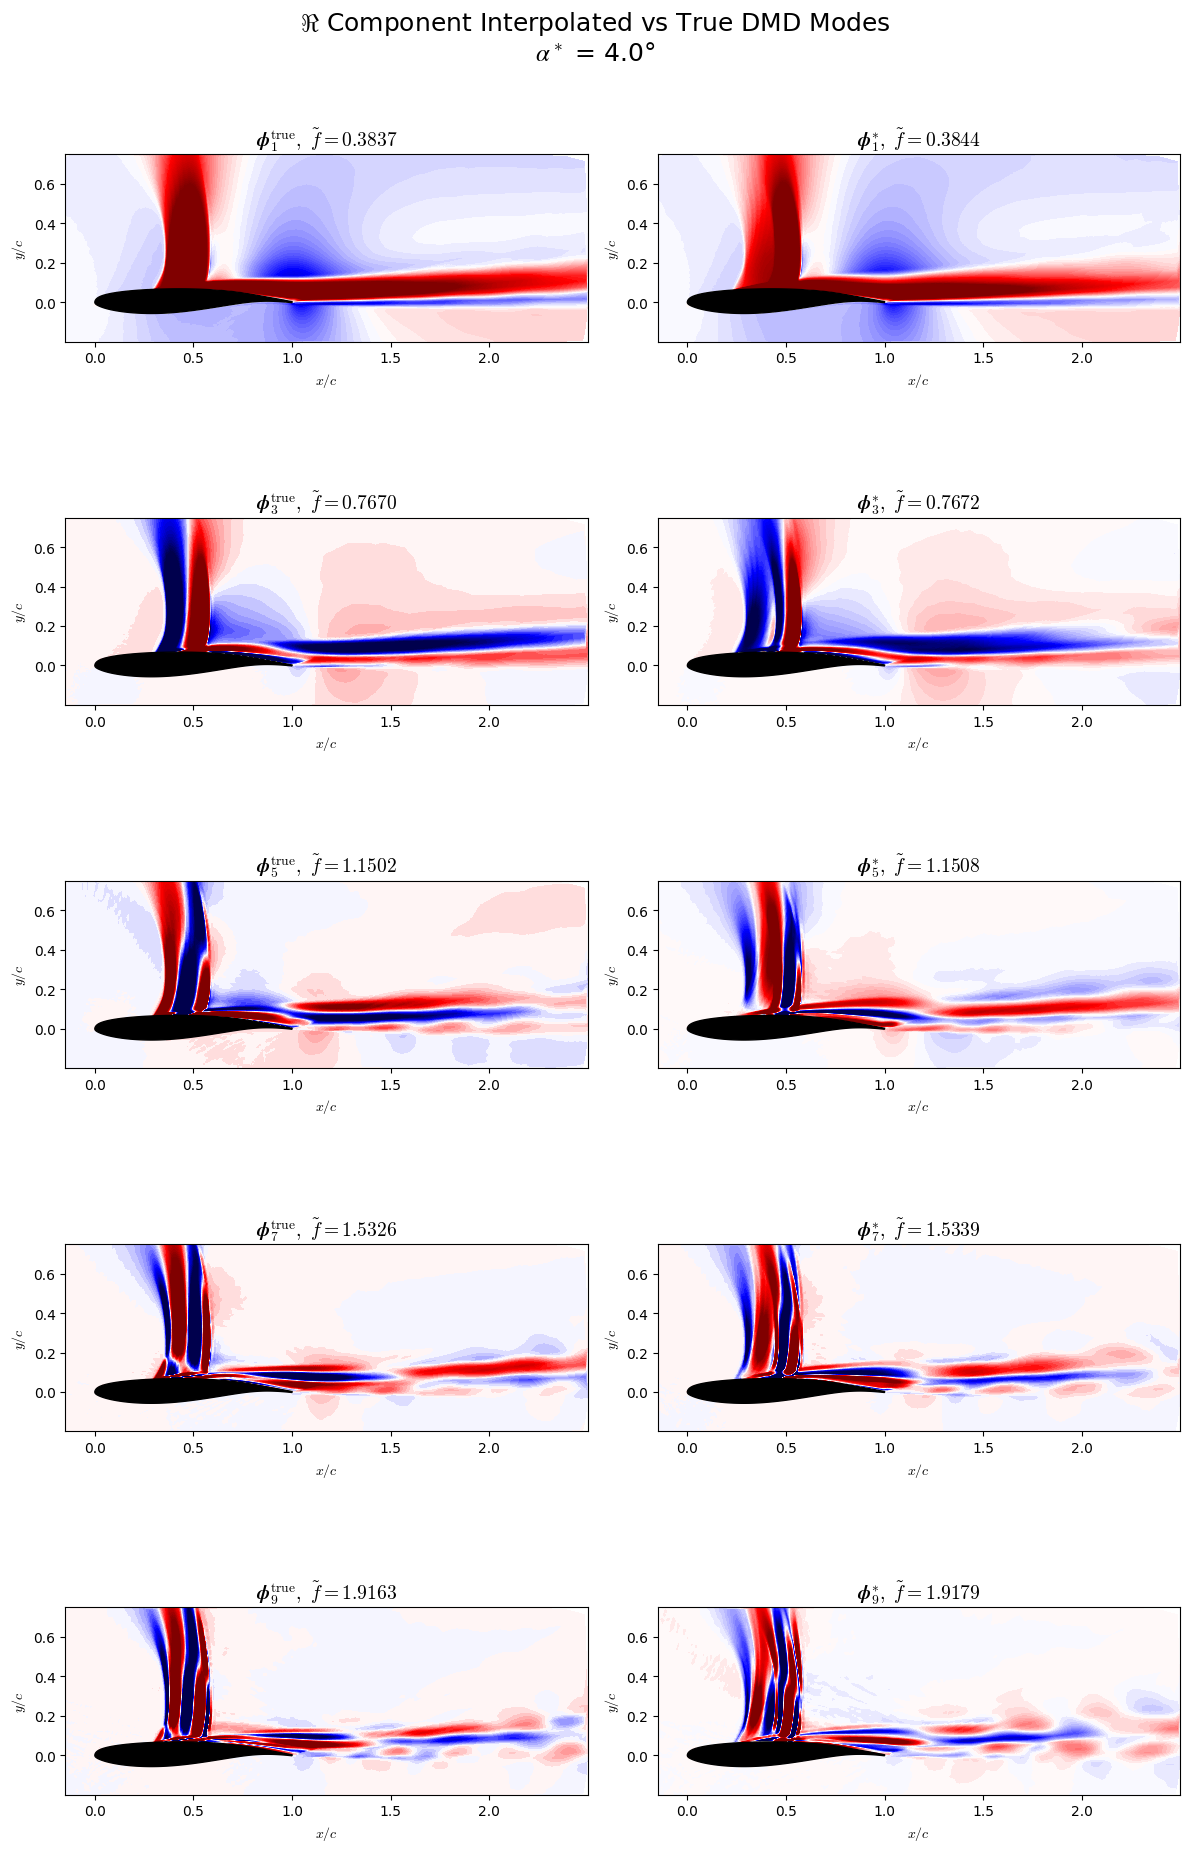

In [25]:
# Plot real component of true vs predicted mode

Np = 2
modes_to_show = 5

coords = train_data.coords
coords_nd = coords / c_ref
num_points = train_data.num_points

# Load interpolated and test-aligned modes (already sorted/paired for test)
Phi_interp = interp_modes[Np]          # corrected
Phi_true   = Phi_test_aligned

# Remove Cl row
Phi_interp = Phi_interp[:-1, :]
Phi_true   = Phi_true[:-1, :]

# Remove conjugate pairs based on interpolated eigenvalues
s_interp_full = interp_eigs[Np]        # corrected
freqs_interp_full = s_interp_full.imag

unique_idx = []
used = set()
for i, w in enumerate(freqs_interp_full):
    key = round(abs(float(w)), 8)
    if key not in used:
        used.add(key)
        unique_idx.append(i)

# Apply conjugate-pair filtering to modes and eigenvalues
Phi_interp = Phi_interp[:, unique_idx]
Phi_true   = Phi_true[:, unique_idx]
s_interp   = s_interp_full[unique_idx]

# Apply same selection to sorted/paired test eigenvalues
s_test_sel = ordered_eigs_test[unique_idx]

# True frequencies from FlowTorch (already sorted by top_idx_test)
freqs_true_raw = dmd_test.frequency.detach().cpu().numpy()
freqs_true_sorted = freqs_true_raw[top_idx_test[:top_k_test]]
freqs_true_sel = freqs_true_sorted[unique_idx]

# Remove mean mode (index 0)
Phi_interp = Phi_interp[:, 1:]
Phi_true   = Phi_true[:, 1:]
s_interp   = s_interp[1:]
s_test_sel = s_test_sel[1:]
freqs_true_sel = freqs_true_sel[1:]

# Extract Ma(x) block
Phi_interp = Phi_interp[:num_points, :]
Phi_true   = Phi_true[:num_points, :]

# Number of modes to show
r = Phi_interp.shape[1]
modes_to_show = min(modes_to_show, r)

# GLOBAL COLOR NORMALIZATION
global_lim = 0.0
for k in range(modes_to_show):
    phi_interp = Phi_interp[:, k].real
    phi_true   = Phi_true[:, k].real
    global_lim = max(global_lim,
                     np.max(np.abs(phi_interp)),
                     np.max(np.abs(phi_true)))*0.2

# PLOTTING

fig, axarr = plt.subplots(modes_to_show, 2, figsize=(12, 4*modes_to_show))
if modes_to_show == 1:
    axarr = np.array([axarr])

for k in range(modes_to_show):

    # Real part of spatial modes
    phi_interp = Phi_interp[:, k].real
    phi_true   = Phi_true[:, k].real

    # Interpolated normalized frequency
    omega_i = float(s_interp[k].imag)
    f_tilde_i = omega_i * c_ref / U_ref

    # True normalized frequency from FlowTorch frequency()
    f_true_hz = abs(freqs_true_sel[k])
    omega_true = 2 * np.pi * f_true_hz
    f_tilde_true = omega_true * c_ref / U_ref

    # Mode numbering convention
    mode_number = 2 * k + 1

    # Titles
    title_interp = rf"$\boldsymbol{{\phi}}_{{{mode_number}}}^{{*}},\ \tilde f={f_tilde_i:.4f}$"
    title_true   = rf"$\boldsymbol{{\phi}}_{{{mode_number}}}^{{\mathrm{{true}}}},\ \tilde f={f_tilde_true:.4f}$"

    # TRUE ON THE LEFT
    ax = axarr[k, 0]
    ax.tricontourf(coords_nd[:, 0], coords_nd[:, 1], phi_true,
                   levels=300, cmap='seismic',
                   vmin=-global_lim, vmax=global_lim)
    draw_airfoil_patch(ax)
    ax.set_title(title_true, fontsize=14)
    ax.set_aspect('equal')

    # INTERPOLATED ON THE RIGHT
    ax = axarr[k, 1]
    ax.tricontourf(coords_nd[:, 0], coords_nd[:, 1], phi_interp,
                   levels=300, cmap='seismic',
                   vmin=-global_lim, vmax=global_lim)
    draw_airfoil_patch(ax)
    ax.set_title(title_interp, fontsize=14)
    ax.set_aspect('equal')

    # Axis labels
    for j in range(2):
        axarr[k, j].set_xlabel(r"$x/c$")
        axarr[k, j].set_ylabel(r"$y/c$")
        axarr[k, j].tick_params(labelbottom=True, labelleft=True)

# Figure title
fig.suptitle(
    rf"$\Re$ Component Interpolated vs True DMD Modes"
    f"\n$α^*$ = {alpha_test}°",
    fontsize=18, y=0.95
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


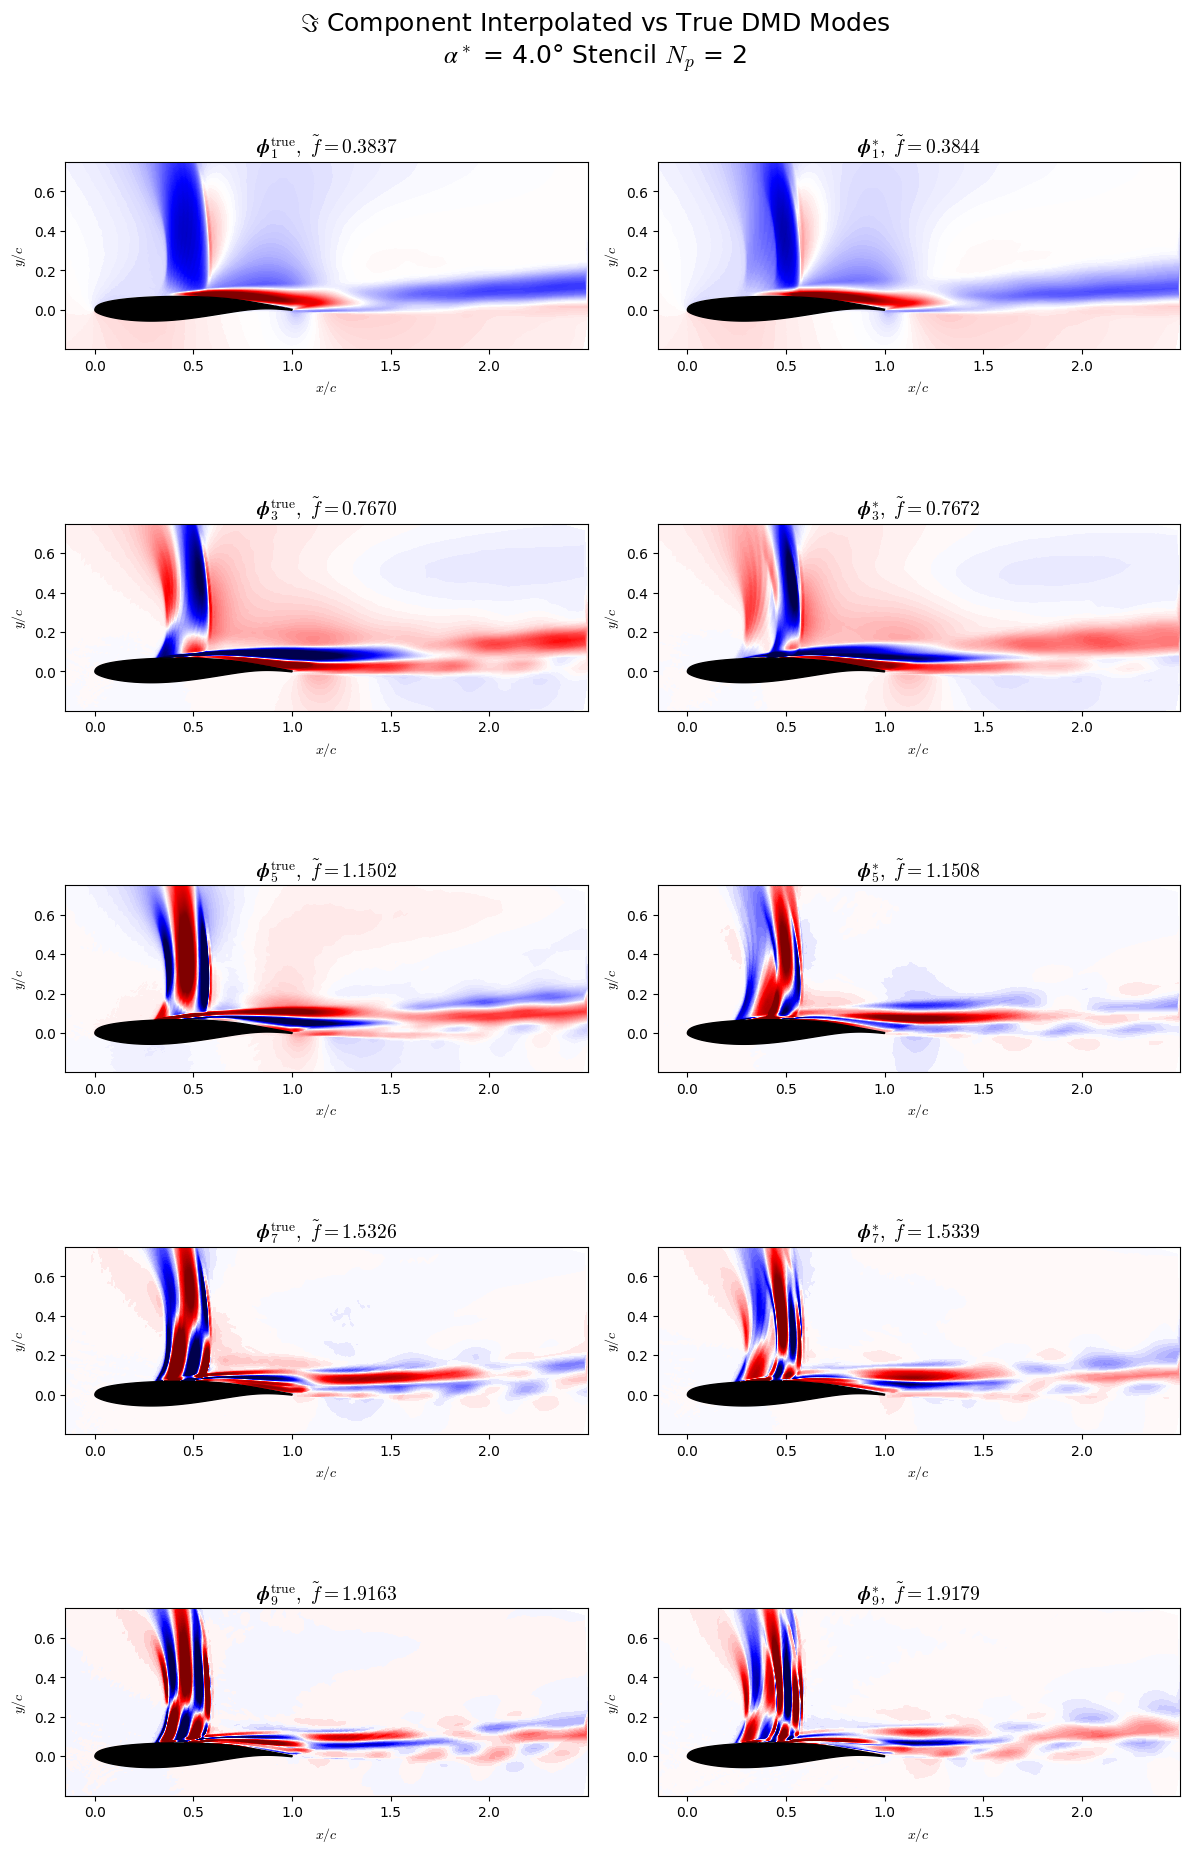

In [26]:
# Plot imaginary component of true vs predicted mode

Np = 2
modes_to_show = 5

coords = train_data.coords
coords_nd = coords / c_ref
num_points = train_data.num_points

# Load interpolated and test-aligned modes (already sorted/paired for test)
Phi_interp = interp_modes[Np]
Phi_true   = Phi_test_aligned

# Remove Cl row
Phi_interp = Phi_interp[:-1, :]
Phi_true   = Phi_true[:-1, :]

# Remove conjugate pairs based on interpolated eigenvalues
s_interp_full = interp_eigs[Np]
freqs_interp_full = s_interp_full.imag

unique_idx = []
used = set()
for i, w in enumerate(freqs_interp_full):
    key = round(abs(float(w)), 8)
    if key not in used:
        used.add(key)
        unique_idx.append(i)

# Apply conjugate-pair filtering
Phi_interp = Phi_interp[:, unique_idx]
Phi_true   = Phi_true[:, unique_idx]
s_interp   = s_interp_full[unique_idx]
s_test_sel = ordered_eigs_test[unique_idx]

# True frequencies from FlowTorch
freqs_true_raw = dmd_test.frequency.detach().cpu().numpy()
freqs_true_sorted = freqs_true_raw[top_idx_test[:top_k_test]]
freqs_true_sel = freqs_true_sorted[unique_idx]

# Remove mean mode
Phi_interp = Phi_interp[:, 1:]
Phi_true   = Phi_true[:, 1:]
s_interp   = s_interp[1:]
s_test_sel = s_test_sel[1:]
freqs_true_sel = freqs_true_sel[1:]

# Extract Ma(x) block
Phi_interp = Phi_interp[:num_points, :]
Phi_true   = Phi_true[:num_points, :]

# Number of modes to show
r = Phi_interp.shape[1]
modes_to_show = min(modes_to_show, r)

# GLOBAL COLOR NORMALIZATION
global_lim = 0.0
for k in range(modes_to_show):
    phi_interp = Phi_interp[:, k].imag
    phi_true   = Phi_true[:, k].imag
    global_lim = max(global_lim,
                     np.max(np.abs(phi_interp)),
                     np.max(np.abs(phi_true)))*0.2

# PLOTTING

fig, axarr = plt.subplots(modes_to_show, 2, figsize=(12, 4*modes_to_show))
if modes_to_show == 1:
    axarr = np.array([axarr])

for k in range(modes_to_show):

    # Imag part of spatial modes
    phi_interp = Phi_interp[:, k].imag
    phi_true   = Phi_true[:, k].imag

    # Interpolated normalized frequency
    omega_i = float(s_interp[k].imag)
    f_tilde_i = omega_i * c_ref / U_ref

    # True normalized frequency
    f_true_hz = abs(freqs_true_sel[k])
    omega_true = 2 * np.pi * f_true_hz
    f_tilde_true = omega_true * c_ref / U_ref

    # Mode numbering
    mode_number = 2 * k + 1

    # Titles
    title_interp = rf"$\boldsymbol{{\phi}}_{{{mode_number}}}^{{*}},\ \tilde f={f_tilde_i:.4f}$"
    title_true   = rf"$\boldsymbol{{\phi}}_{{{mode_number}}}^{{\mathrm{{true}}}},\ \tilde f={f_tilde_true:.4f}$"

    # TRUE (left)
    ax = axarr[k, 0]
    ax.tricontourf(coords_nd[:, 0], coords_nd[:, 1], phi_true,
                   levels=300, cmap='seismic',
                   vmin=-global_lim, vmax=global_lim)
    draw_airfoil_patch(ax)
    ax.set_title(title_true, fontsize=14)
    ax.set_aspect('equal')

    # INTERPOLATED (right)
    ax = axarr[k, 1]
    ax.tricontourf(coords_nd[:, 0], coords_nd[:, 1], phi_interp,
                   levels=300, cmap='seismic',
                   vmin=-global_lim, vmax=global_lim)
    draw_airfoil_patch(ax)
    ax.set_title(title_interp, fontsize=14)
    ax.set_aspect('equal')

    # Axis labels
    for j in range(2):
        axarr[k, j].set_xlabel(r"$x/c$")
        axarr[k, j].set_ylabel(r"$y/c$")
        axarr[k, j].tick_params(labelbottom=True, labelleft=True)

# Figure title
fig.suptitle(
    rf"$\Im$ Component Interpolated vs True DMD Modes"
    f"\n$α^*$ = {alpha_test}° Stencil $N_p$ = {Np}",
    fontsize=18, y=0.95
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


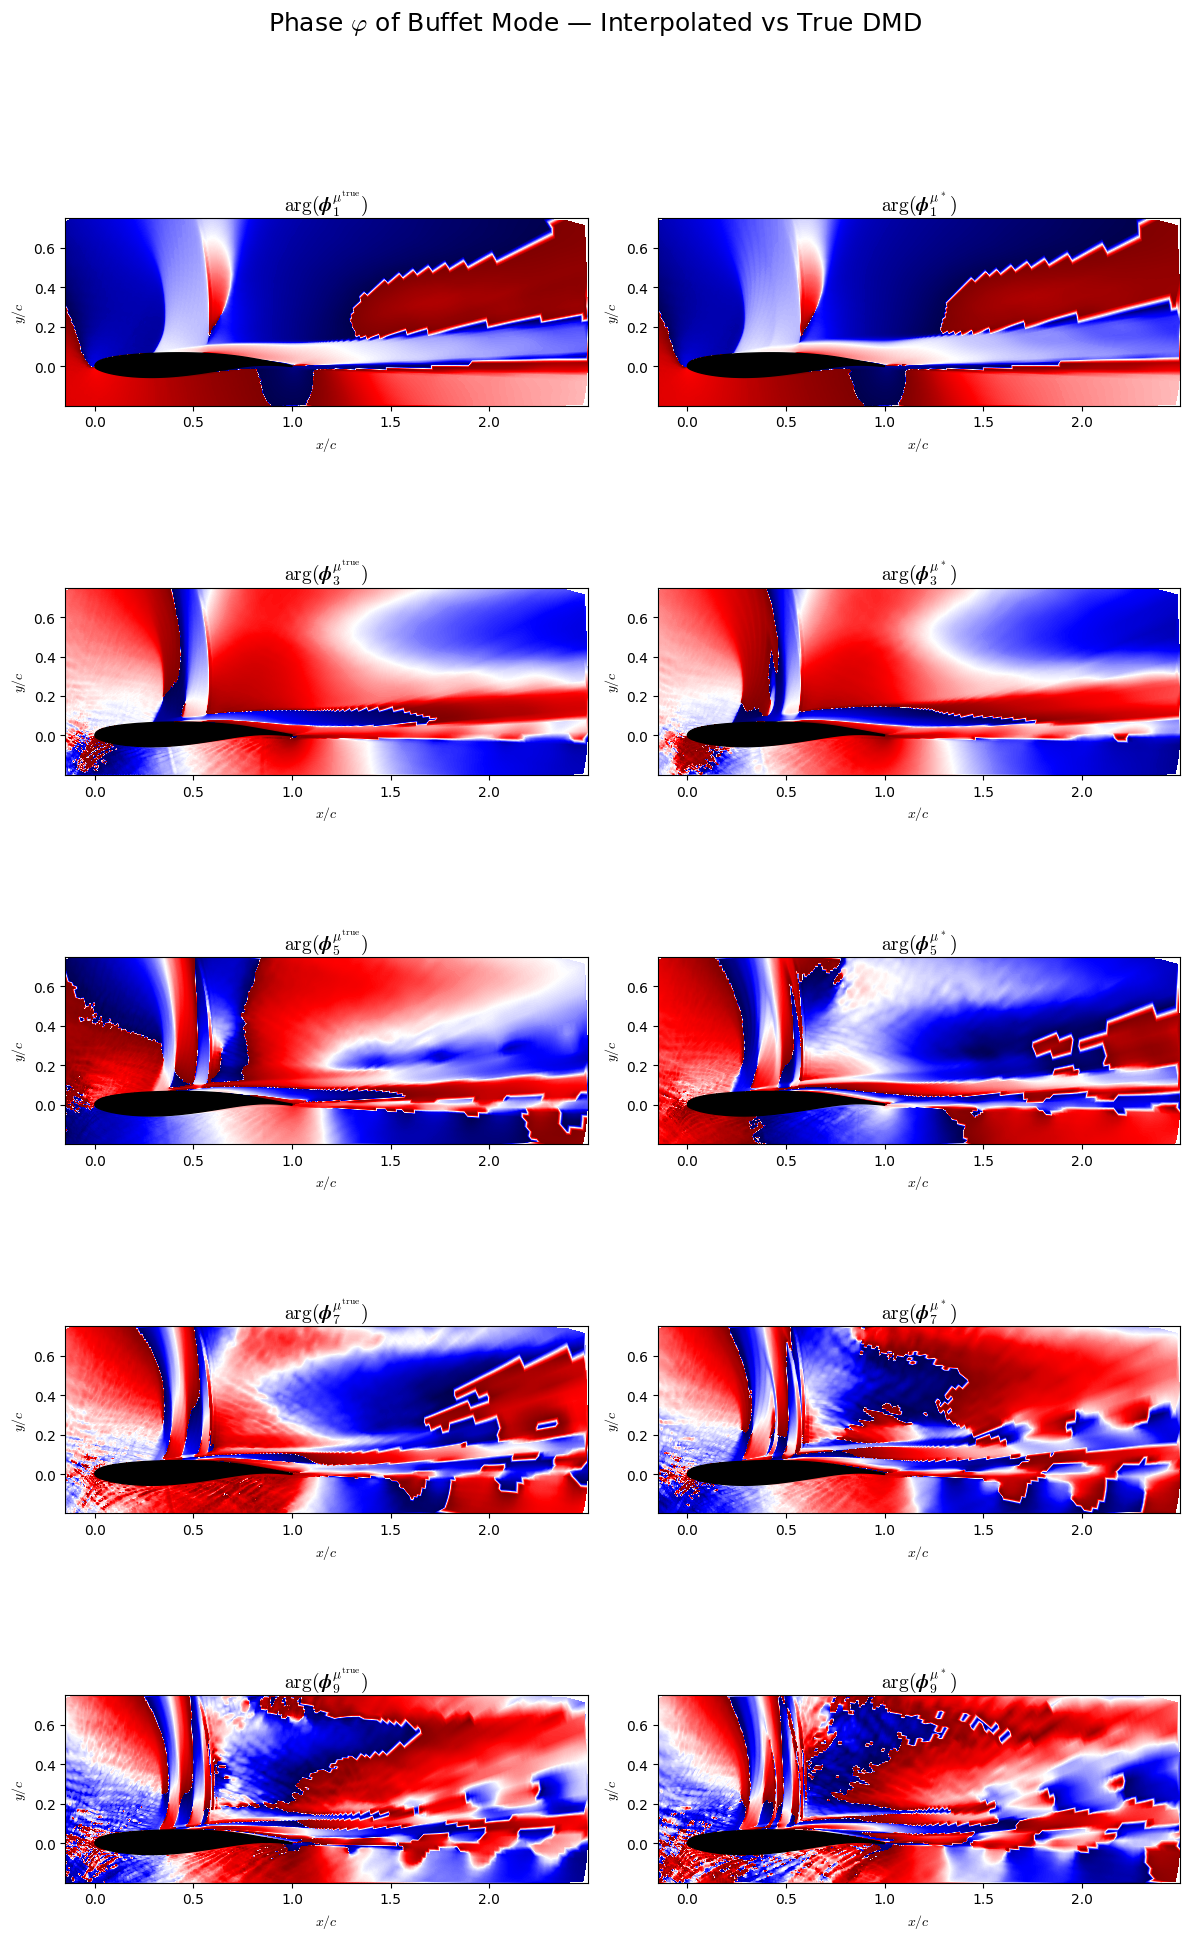

In [27]:
# Plot phase of true vs predicted mode

Np = 2
modes_to_show = 5

coords = train_data.coords
coords_nd = coords / c_ref
num_points = train_data.num_points

# Interpolated vs true TEST modes (already sorted/paired)
Phi_interp = interp_modes[Np]          # corrected
Phi_true   = Phi_test_aligned

# Keep only Ma(x) block (remove Cl)
Phi_interp = Phi_interp[:num_points, :]
Phi_true   = Phi_true[:num_points, :]

# Interpolated eigenvalues (already aligned)
s_interp_full = interp_eigs[Np]        # corrected
freqs_interp_full = s_interp_full.imag

# Remove conjugate pairs based on interpolated eigenvalues
unique_idx = []
used = set()
for i, w in enumerate(freqs_interp_full):
    key = round(abs(float(w)), 8)
    if key not in used:
        used.add(key)
        unique_idx.append(i)

Phi_interp = Phi_interp[:, unique_idx]
Phi_true   = Phi_true[:, unique_idx]
s_interp   = s_interp_full[unique_idx]

# Apply same selection to true continuous-time eigenvalues
s_test_sel = ordered_eigs_test[unique_idx]

# Remove mean mode (index 0)
Phi_interp = Phi_interp[:, 1:]
Phi_true   = Phi_true[:, 1:]
s_interp   = s_interp[1:]
s_test_sel = s_test_sel[1:]

# Number of modes to show
r = Phi_interp.shape[1]
modes_to_show = min(modes_to_show, r)

fig, axarr = plt.subplots(modes_to_show, 2, figsize=(12, 4*modes_to_show))
if modes_to_show == 1:
    axarr = np.array([axarr])

cmap_phase = "seismic"

for k in range(modes_to_show):

    # Complex scalar mode
    phi_interp = Phi_interp[:, k]
    phi_true   = Phi_true[:, k]

    # Phase fields
    phase_interp = np.angle(phi_interp)
    phase_true   = np.angle(phi_true)

    # Correct mode numbering
    mode_number = 2 * k + 1

    # Titles
    title_interp = rf"$\arg(\boldsymbol{{\phi}}_{{{mode_number}}}^{{\mu^\ast}})$"
    title_true   = rf"$\arg(\boldsymbol{{\phi}}_{{{mode_number}}}^{{\mu^{{\mathrm{{true}}}}}})$"

    # TRUE PHASE ON THE LEFT
    ax = axarr[k, 0]
    ax.tricontourf(coords_nd[:, 0], coords_nd[:, 1], phase_true,
                   levels=300, cmap=cmap_phase)
    draw_airfoil_patch(ax)
    ax.set_title(title_true, fontsize=14)
    ax.set_aspect("equal")

    # INTERPOLATED PHASE ON THE RIGHT
    ax = axarr[k, 1]
    ax.tricontourf(coords_nd[:, 0], coords_nd[:, 1], phase_interp,
                   levels=300, cmap=cmap_phase)
    draw_airfoil_patch(ax)
    ax.set_title(title_interp, fontsize=14)
    ax.set_aspect("equal")

    # Axis labels
    for j in range(2):
        axarr[k, j].set_xlabel(r"$x/c$")
        axarr[k, j].set_ylabel(r"$y/c$")
        axarr[k, j].tick_params(labelbottom=True, labelleft=True)

fig.suptitle(
    rf"Phase $\varphi$ of Buffet Mode — Interpolated vs True DMD",
    fontsize=18, y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


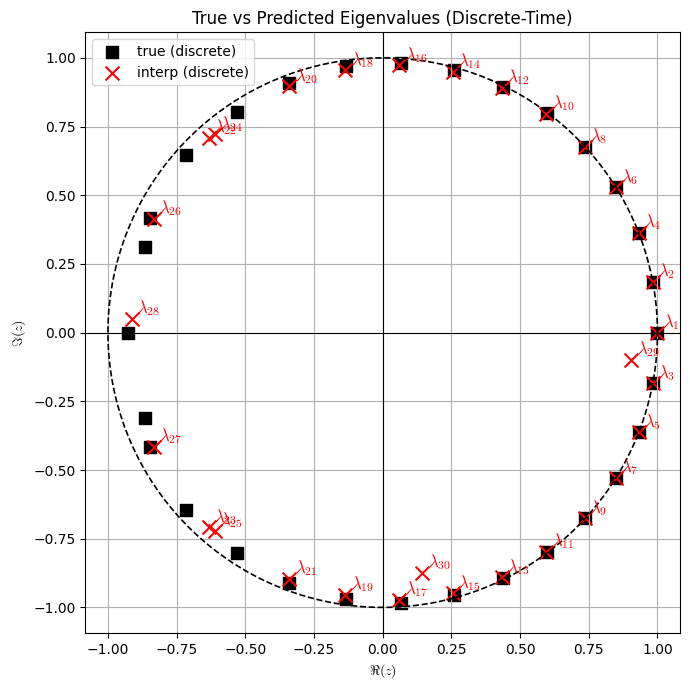

In [29]:
# Choose how many eigenvalues to plot
num_eigs = 30 

s_interp = interp_eigs[Np]      
s_true   = ordered_eigs_test

times = train_data.times[alpha_list[0]]
times = np.array(times, dtype=float)

dt = times[1] - times[0]  # sampling time

# Convert continuous eigenvalues to discrete-time
z_interp = np.exp(s_interp * dt)
z_true   = np.exp(s_true   * dt)

# Slice the arrays
z_interp_plot = z_interp[:num_eigs]
z_true_plot   = z_true[:num_eigs]

plt.figure(figsize=(7,7))

# True eigenvalues (squares)
plt.scatter(z_true_plot.real, z_true_plot.imag, 
            marker='s', s=80, color='black',label="true (discrete)")

# Interpolated eigenvalues (crosses)
plt.scatter(z_interp_plot.real, z_interp_plot.imag, 
            marker='x', s=100, color='red', label="interp (discrete)")

# Add unit circle
theta = np.linspace(0, 2*np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=1.2)

# Label offset
dx = 0.02
dy = 0.02

# Add labels 
for k, (xr, xi) in enumerate(zip(z_interp_plot.real, z_interp_plot.imag)):
    plt.text(xr + dx, xi + dy,
             rf"$\lambda_{{{k+1}}}$",
             fontsize=12, color='red')

# Axes and formatting
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel(r"$\Re(z)$")
plt.ylabel(r"$\Im(z)$")
plt.title("True vs Predicted Eigenvalues (Discrete-Time)")
plt.grid(True)
plt.legend()
plt.axis('equal')   
plt.tight_layout()
plt.show()
